## Session 4: Visualisation – Static & Interactive

**Date:** 18/05/2026  
**Objective:** Create publication‑quality static visualisations (Matplotlib, Seaborn) and interactive charts (Plotly) to uncover patterns in gaming communities. No statistical hypothesis testing – focus solely on exploratory and explanatory visualisation.

---

### 4.1 Agenda for Session 4

| Part | Activity | Tools | Questions |
|------|----------|-------|-----------|
| **M1** | Histogram of `log_member_count` + KDE | Matplotlib | 1 |
| **M2** | Horizontal bar chart of mean engagement per genre | Matplotlib | 2 |
| **M3** | Scatter plot with trendline coloured by `community_tier` | Matplotlib | 3 |
| **M4** | Boxplot of `tournament_intensity` by `primary_platform` | Matplotlib | 4 |
| **M5** | Dual‑axis plot: line + bars (first 50 communities) | Matplotlib | 5 |
| **M6** | Violin plot of `avg_member_age` by region | Matplotlib | 6 |
| **M7** | Stacked bar chart of community tiers per genre | Matplotlib | 7 |
| **M8** | Error bar chart of coaching staff per tier | Matplotlib | 8 |
| **M9** | Hexbin heatmap of member count vs engagement ratio | Matplotlib | 9 |
| **M10** | 2×2 subplot dashboard | Matplotlib | 10 |
| **S1** | Pairplot of key numeric columns (coloured by genre) | Seaborn | 1 |
| **S2** | FacetGrid histograms of engagement ratio by region & tier | Seaborn | 2 |
| **S3** | Jointplot with KDE and marginal histograms | Seaborn | 3 |
| **S4** | Boxen plot of average member age by region | Seaborn | 4 |
| **S5** | Correlation heatmap with mask | Seaborn | 5 |
| **S6** | FacetGrid: violin + stripplot of tournament intensity by genre | Seaborn | 6 |
| **S7** | Regression plot with confidence band (member count vs social presence) | Seaborn | 7 |
| **S8** | Count plot of coaching percentage per genre (normalised) | Seaborn | 8 |
| **P1** | Interactive bar chart of mean engagement per region (with error bars) | Plotly Express | 1 |
| **P2** | Interactive scatter: size = social presence, colour = tier | Plotly Express | 2 |
| **P3** | 3D scatter plot (member count, engagement, tournament intensity) | Plotly Graph Objects | 3 |
| **P4** | Sunburst chart: region → genre → tier | Plotly Express | 4 |
| **P5** | Interactive line chart of cumulative members for top 3 genres | Plotly Express | 5 |
| **P6** | Box plot with all points and notch | Plotly Express | 6 |
| **P7** | Histogram of log member count with marginal rug | Plotly Express | 7 |
| **P8** | Density heatmap (member count vs active players) with marginals | Plotly Express | 8 |
| **P9** | Bar chart of top 15 countries by total members (choropleth substitute) | Plotly Express | 9 |
| **P10** | make_subplots dashboard: scatter + histogram | Plotly Graph Objects | 10 |

---

### 4.2 Expected Deliverables

- [ ] All 10 Matplotlib visualisations saved as `.png` or `.svg` (optional but recommended).
- [ ] All 8 Seaborn plots with clear interpretations.
- [ ] All 10 Plotly interactive charts displayed in the notebook (saved as HTML if desired).
- [ ] At least three markdown insights explaining what each chart reveals about gaming communities.
- [ ] (Optional) Export interactive charts as standalone HTML files.

---

### 4.3 Tools & Libraries

```python
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import pandas as pd

In [18]:
#importing essential libraries 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import pandas as pd

In [19]:
#loading the dataset
gaming_data = pd.read_csv('gaming_communities_enhanced.csv')

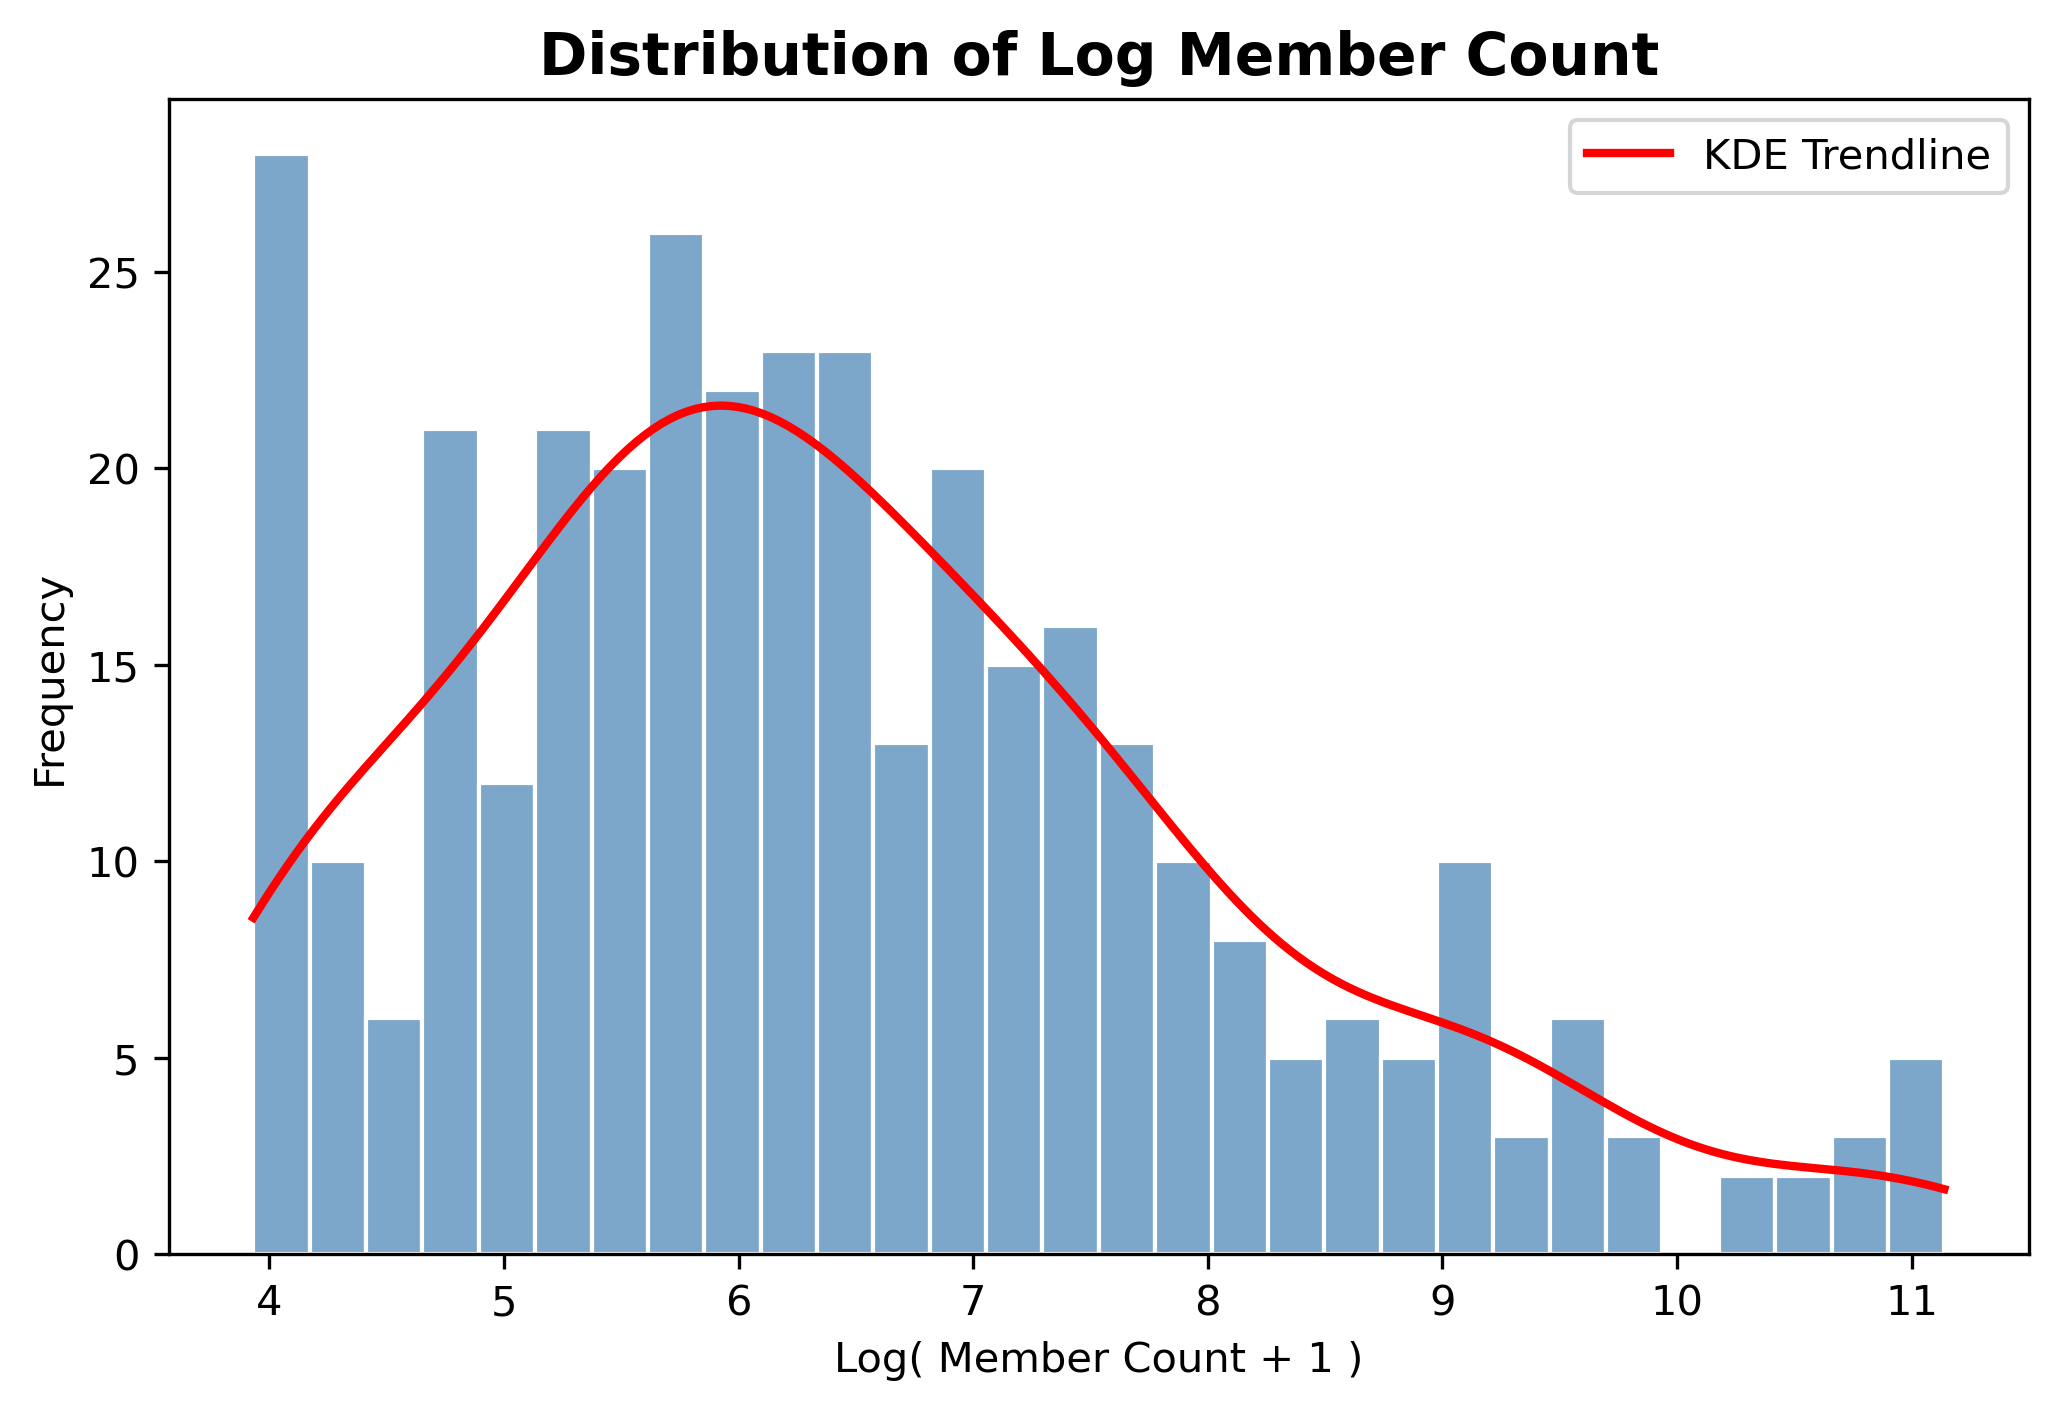

In [25]:
#Histogram of Log Member Count with KDE
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
sns.histplot(
        data = gaming_data,
        x = 'log_member_count',
        bins=30,
        color='steelblue',
        edgecolor='white', 
        alpha=0.7,
        kde=True,
        line_kws={'linewidth':2},
        ax=ax
       )

kde_line = ax.lines[0]
kde_line.set_color('red')              
kde_line.set_label('KDE Trendline')    
ax.set_title('Distribution of Log Member Count', fontweight='bold', fontsize=14)
ax.set_xlabel('Log( Member Count + 1 )')
ax.set_ylabel('Frequency')
ax.legend()

plt.show()

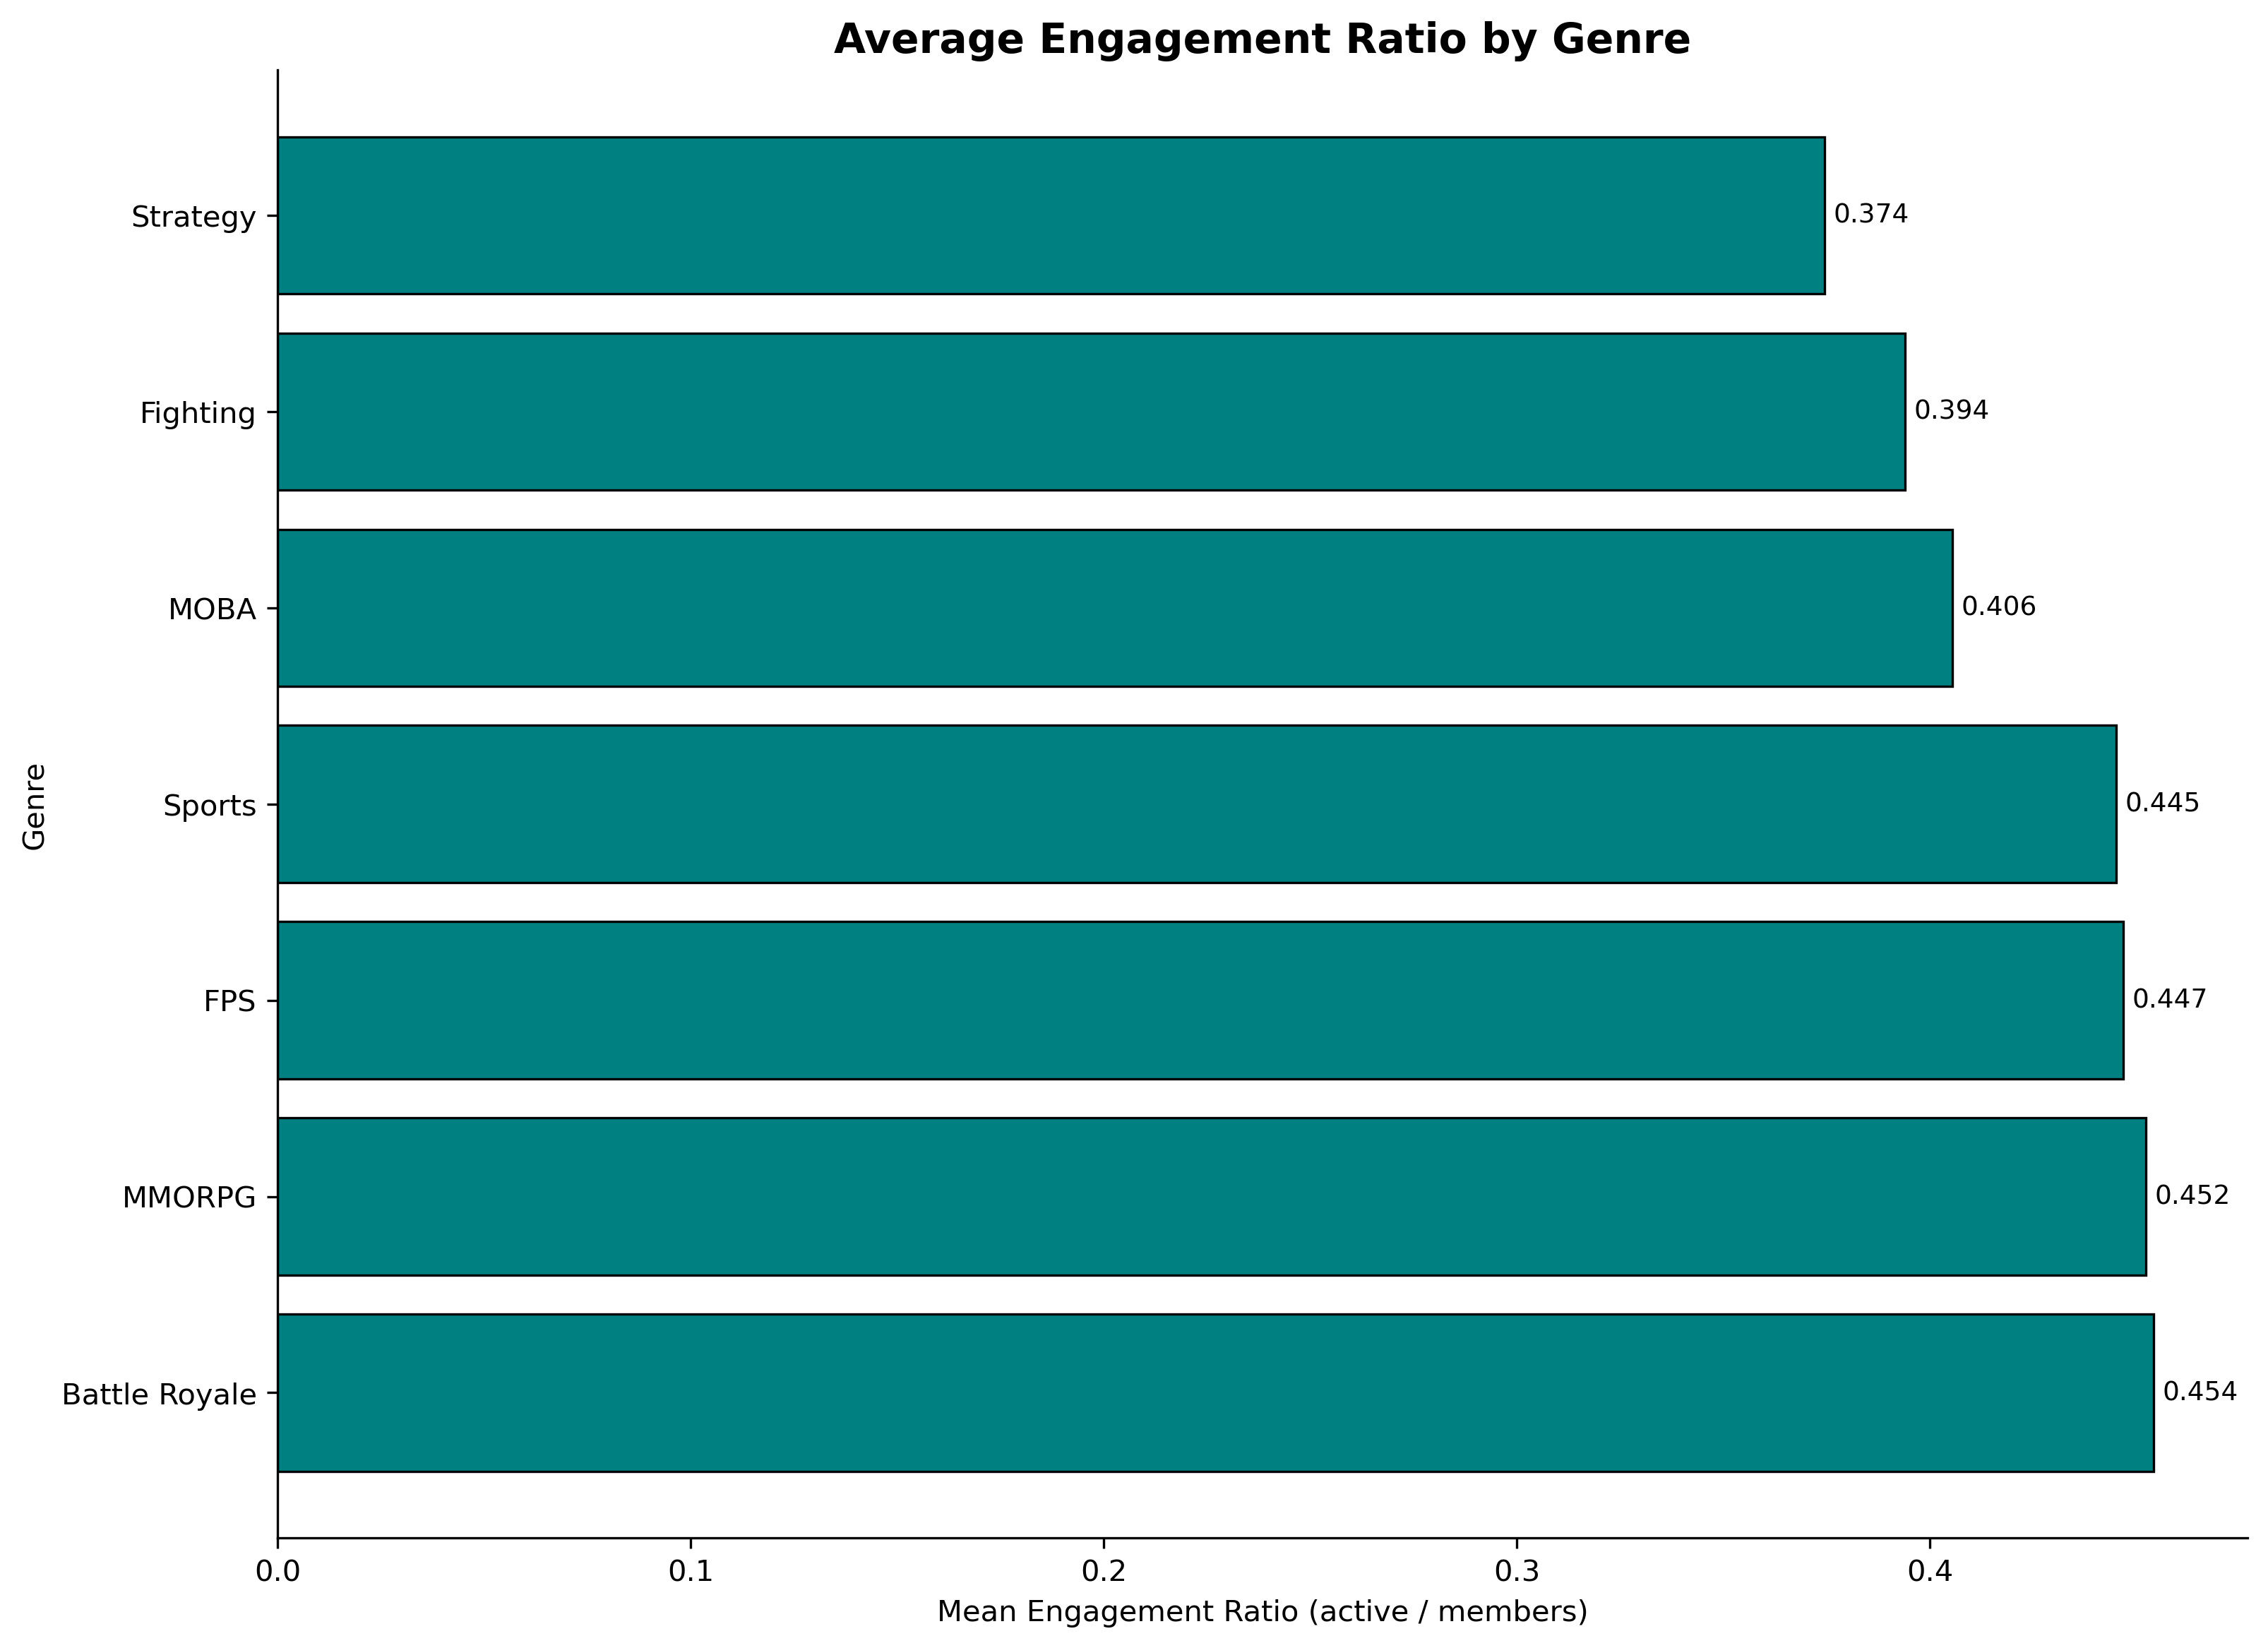

In [46]:
#Horizontal Bar Chart of Mean Engagement Ratio by Genre
genre = gaming_data.groupby(['genre'])['engagement_ratio'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 9), dpi=300)

bars = ax.barh(y=genre.index, width=genre.values,
        color='teal', edgecolor='black', linewidth=0.8,
        )
ax.bar_label(bars, padding=3, fontsize=9, fmt='%.3f')

ax.set_title("Average Engagement Ratio by Genre", fontweight='bold', fontsize=14)
ax.set_xlabel("Mean Engagement Ratio (active / members)")
ax.set_ylabel("Genre")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

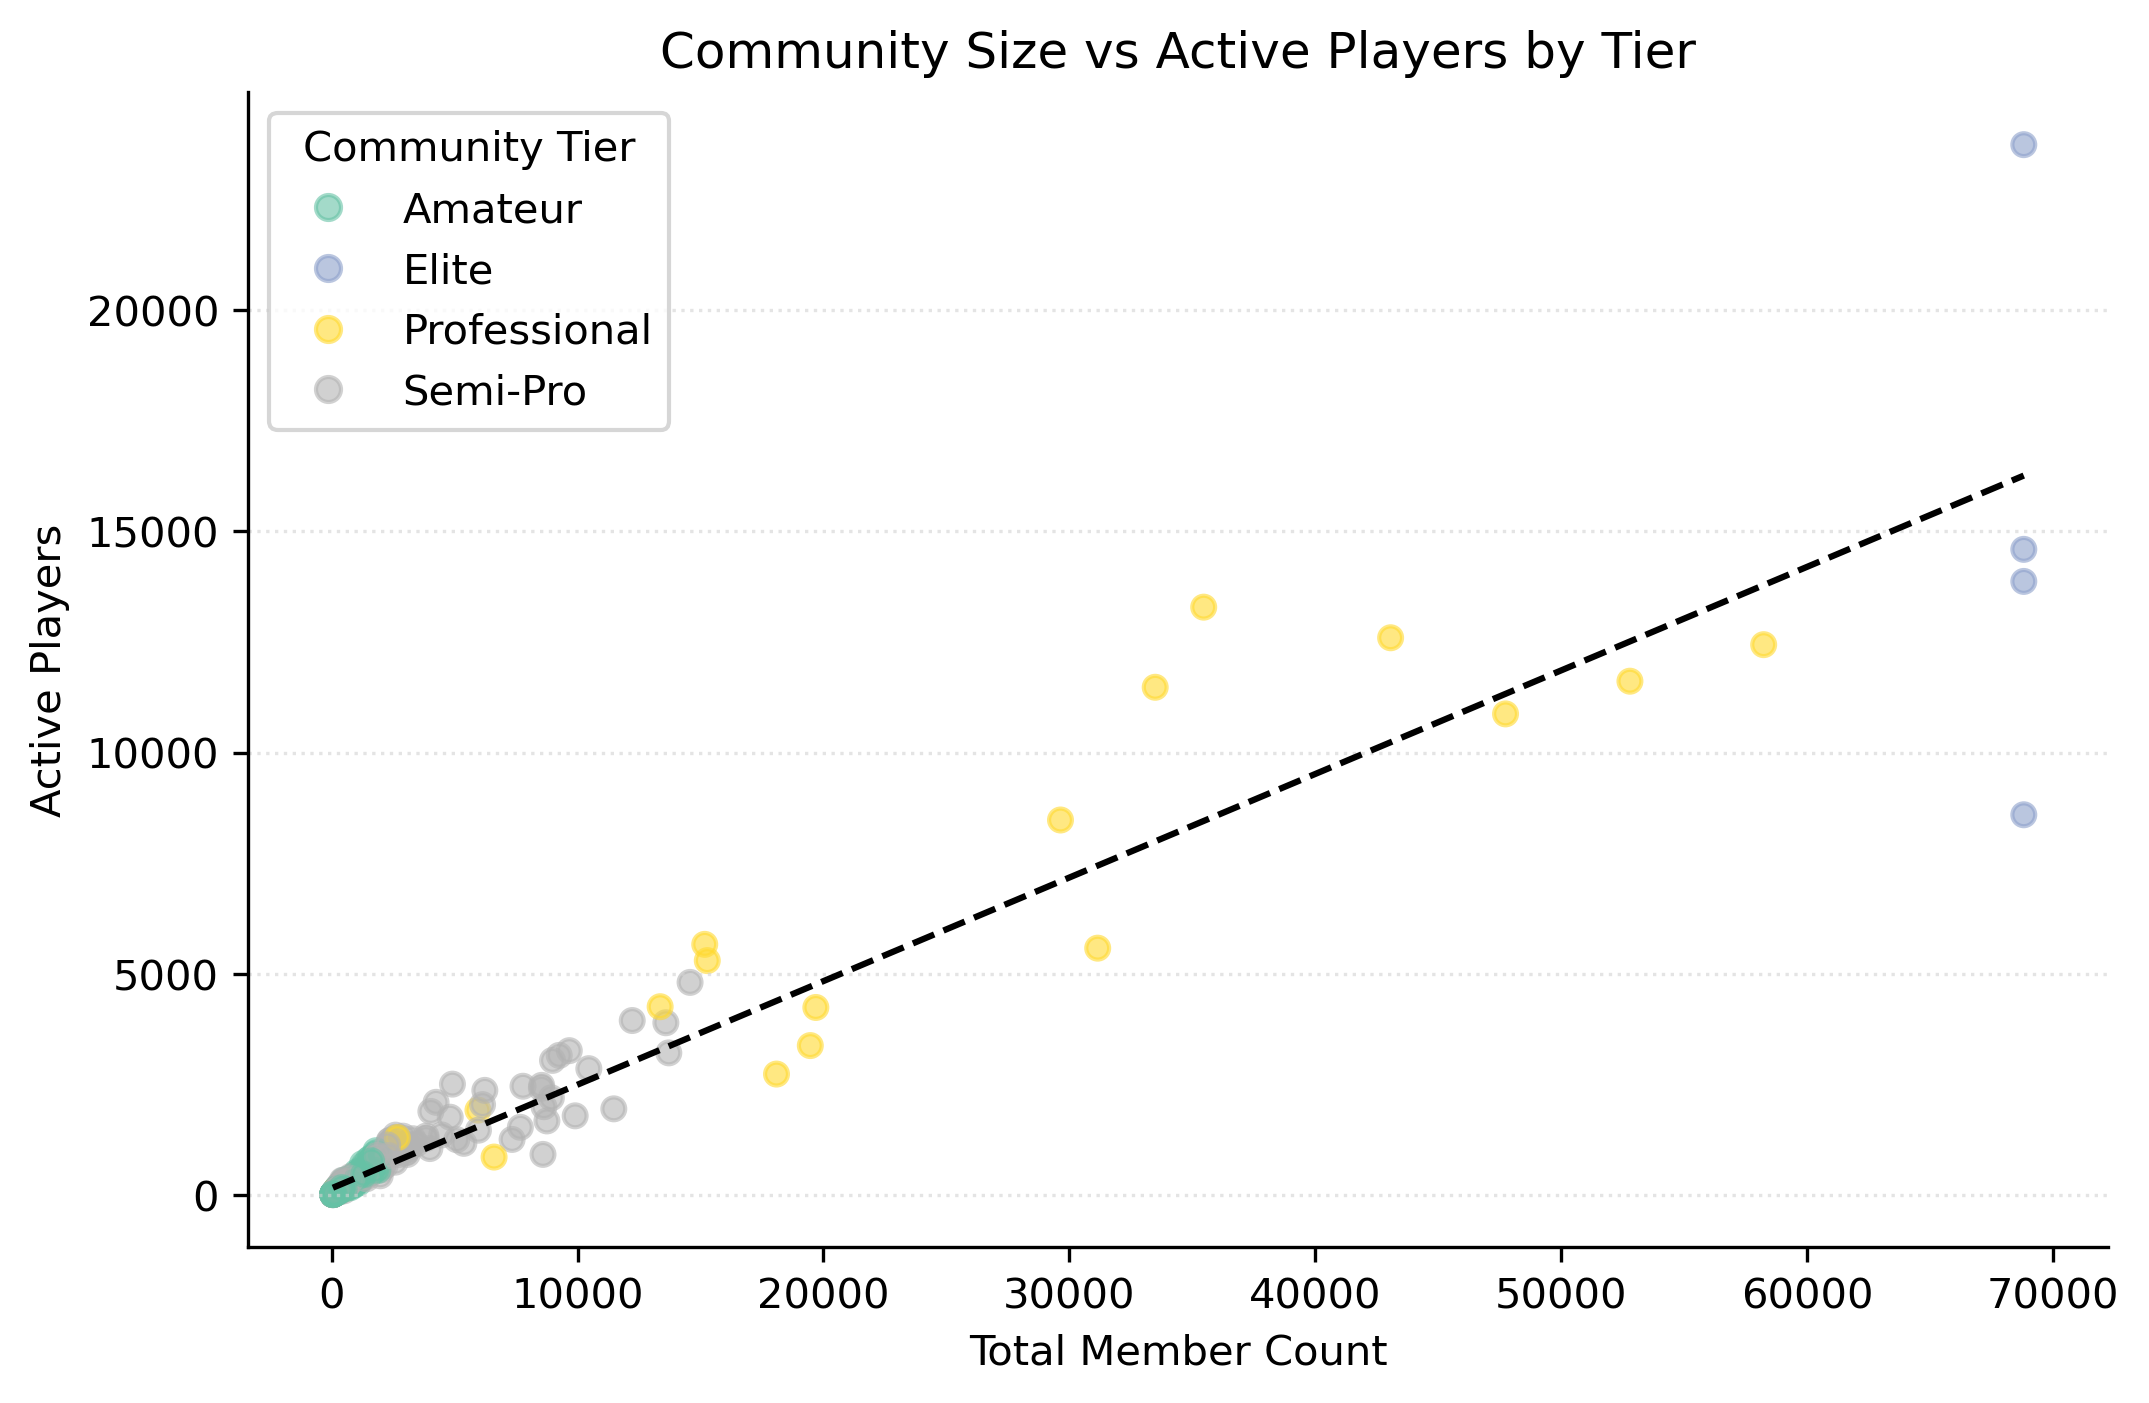

In [57]:
#Scatter Plot of Member Count vs Active Players with Trendline
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

tiers = gaming_data['community_tier'].astype('category')
tier_codes = tiers.cat.codes
tier_names = tiers.cat.categories

scatter = ax.scatter(x=gaming_data['member_count'], y=gaming_data['active_players'], c=tier_codes, alpha=0.6, 
                     s=30, cmap=plt.cm.Set2)

m, b = np.polyfit(gaming_data['member_count'], gaming_data['active_players'], 1)

x_trend = np.array([gaming_data['member_count'].min(), gaming_data['member_count'].max()])
y_trend = m * x_trend + b

ax.plot(
    x_trend, 
    y_trend, 
    color='black', 
    linestyle='--', 
    linewidth=1.5, 
    label='Trendline'
)

handles, _ = scatter.legend_elements()
ax.legend(handles, tier_names, title="Community Tier")

ax.set_title("Community Size vs Active Players by Tier")
ax.set_xlabel("Total Member Count")
ax.set_ylabel("Active Players")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle=':', alpha=0.6, color='lightgrey')

plt.show()

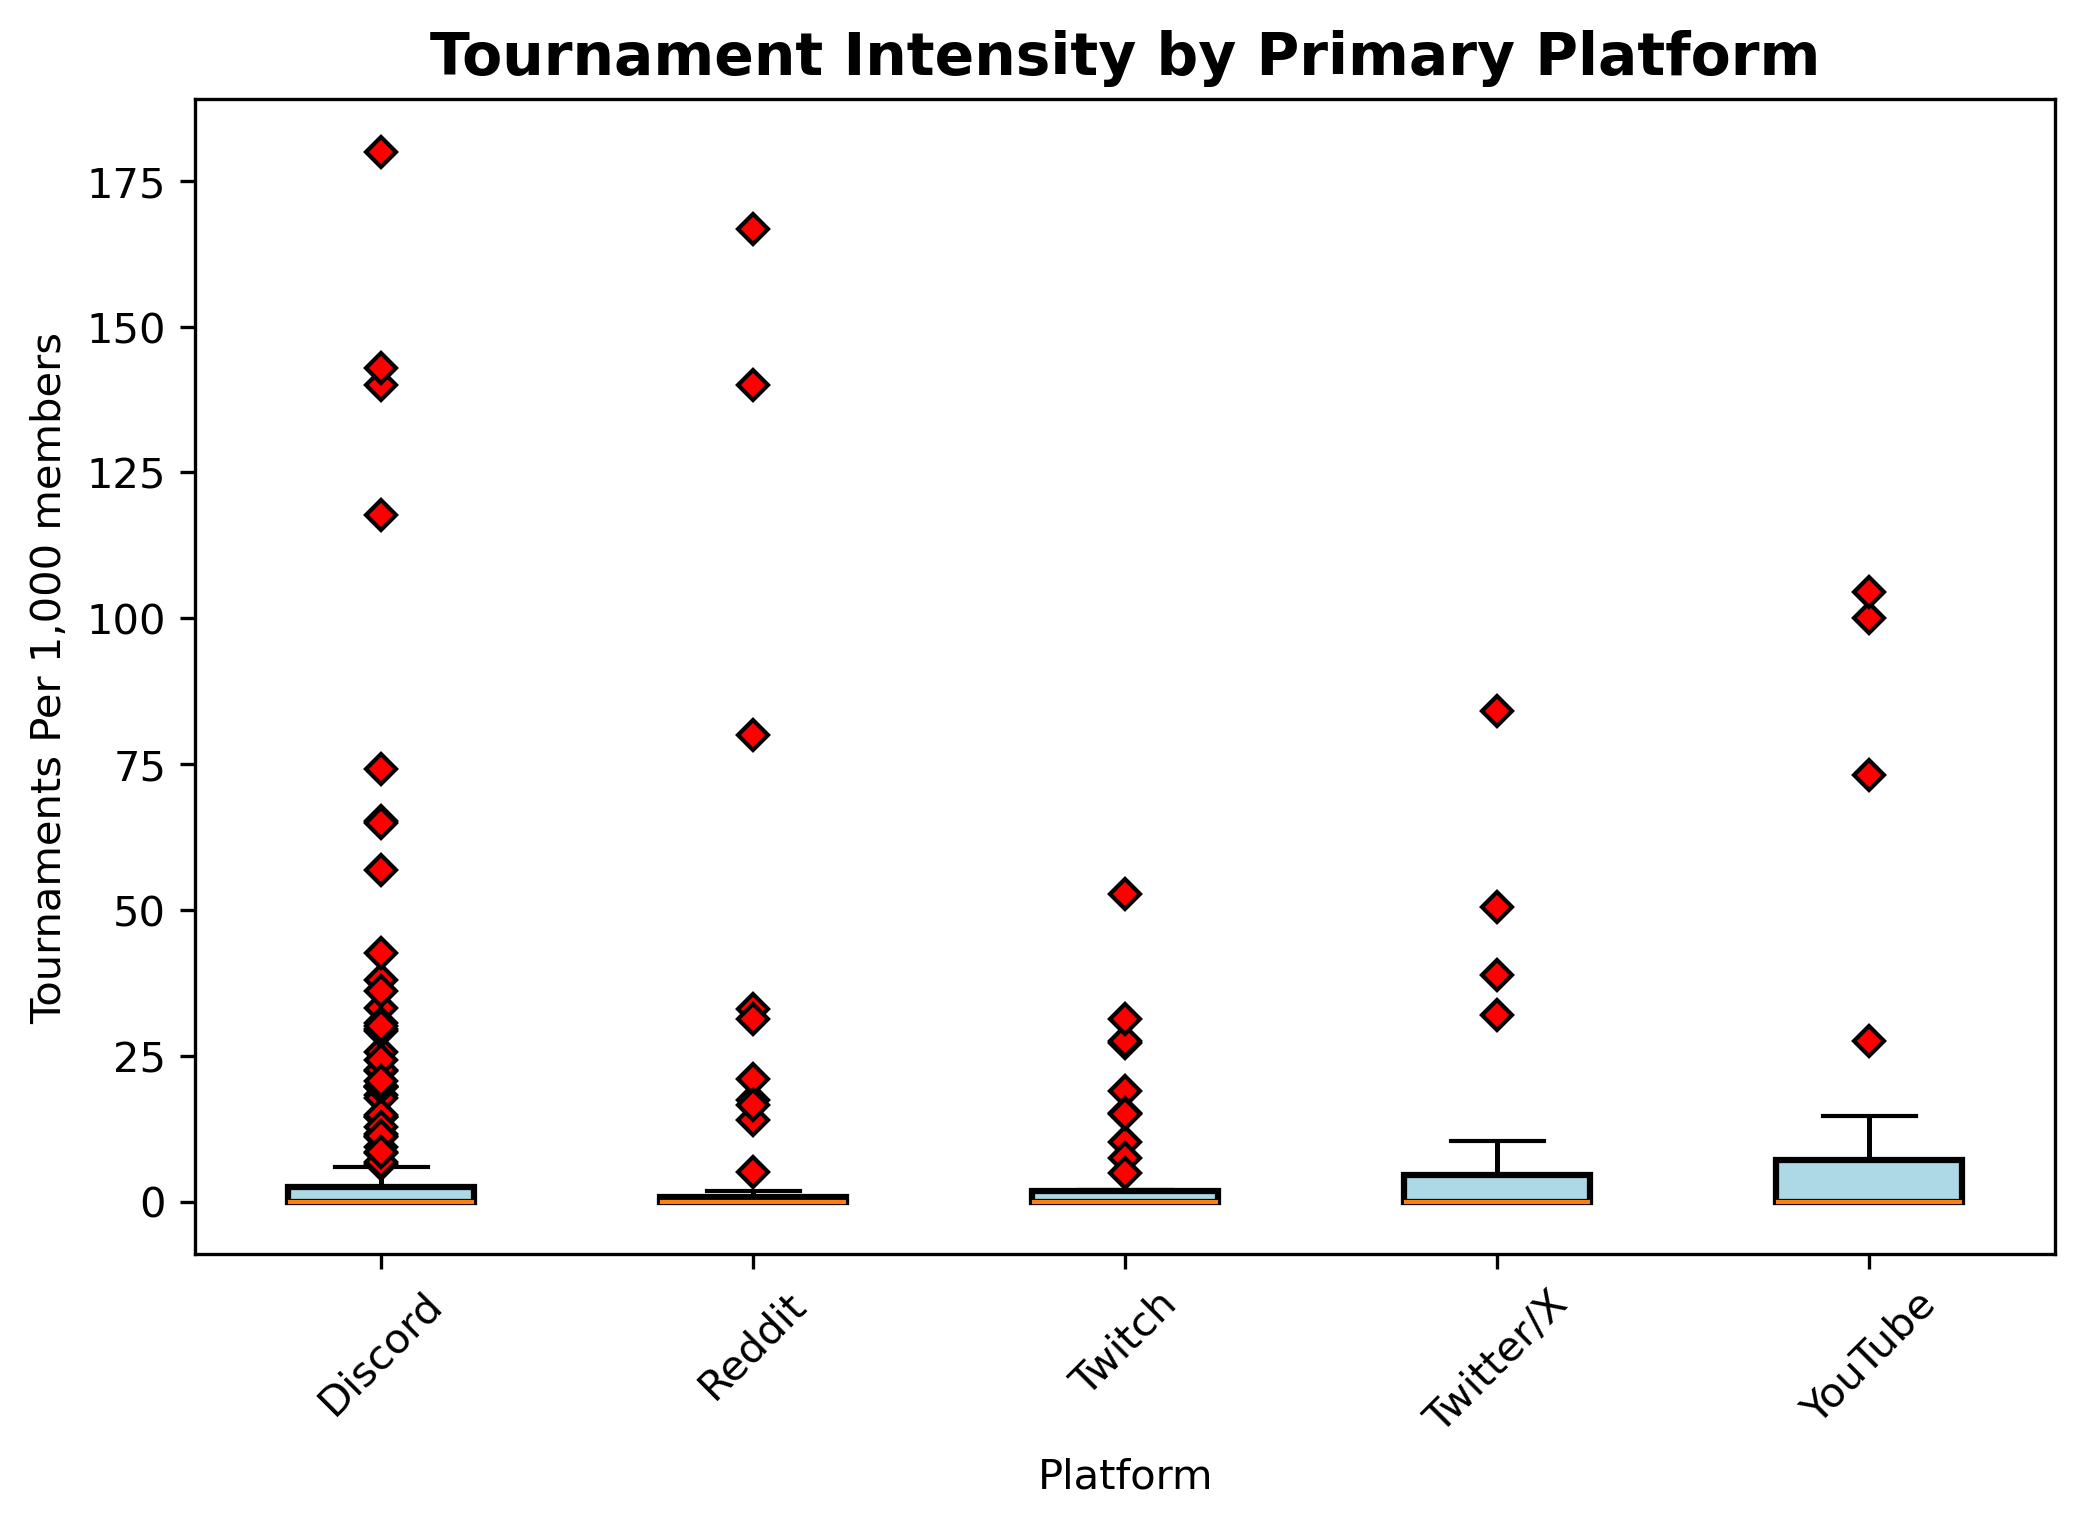

In [68]:
#Boxplot of Tournament Intensity by Primary Platform
data = gaming_data.groupby('primary_platform')['tournament_intensity'].apply(list)
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
ax.boxplot(
    data,
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', linewidth=1.5),
    tick_labels=data.index,
    flierprops=dict(marker='D', markerfacecolor='red', markersize=5),
    whiskerprops=dict(linewidth=1.2)
)

ax.set_title("Tournament Intensity by Primary Platform", fontweight='bold', fontsize=14)
ax.set_xlabel("Platform")
ax.set_ylabel("Tournaments Per 1,000 members")

plt.xticks(rotation=45)

plt.show()

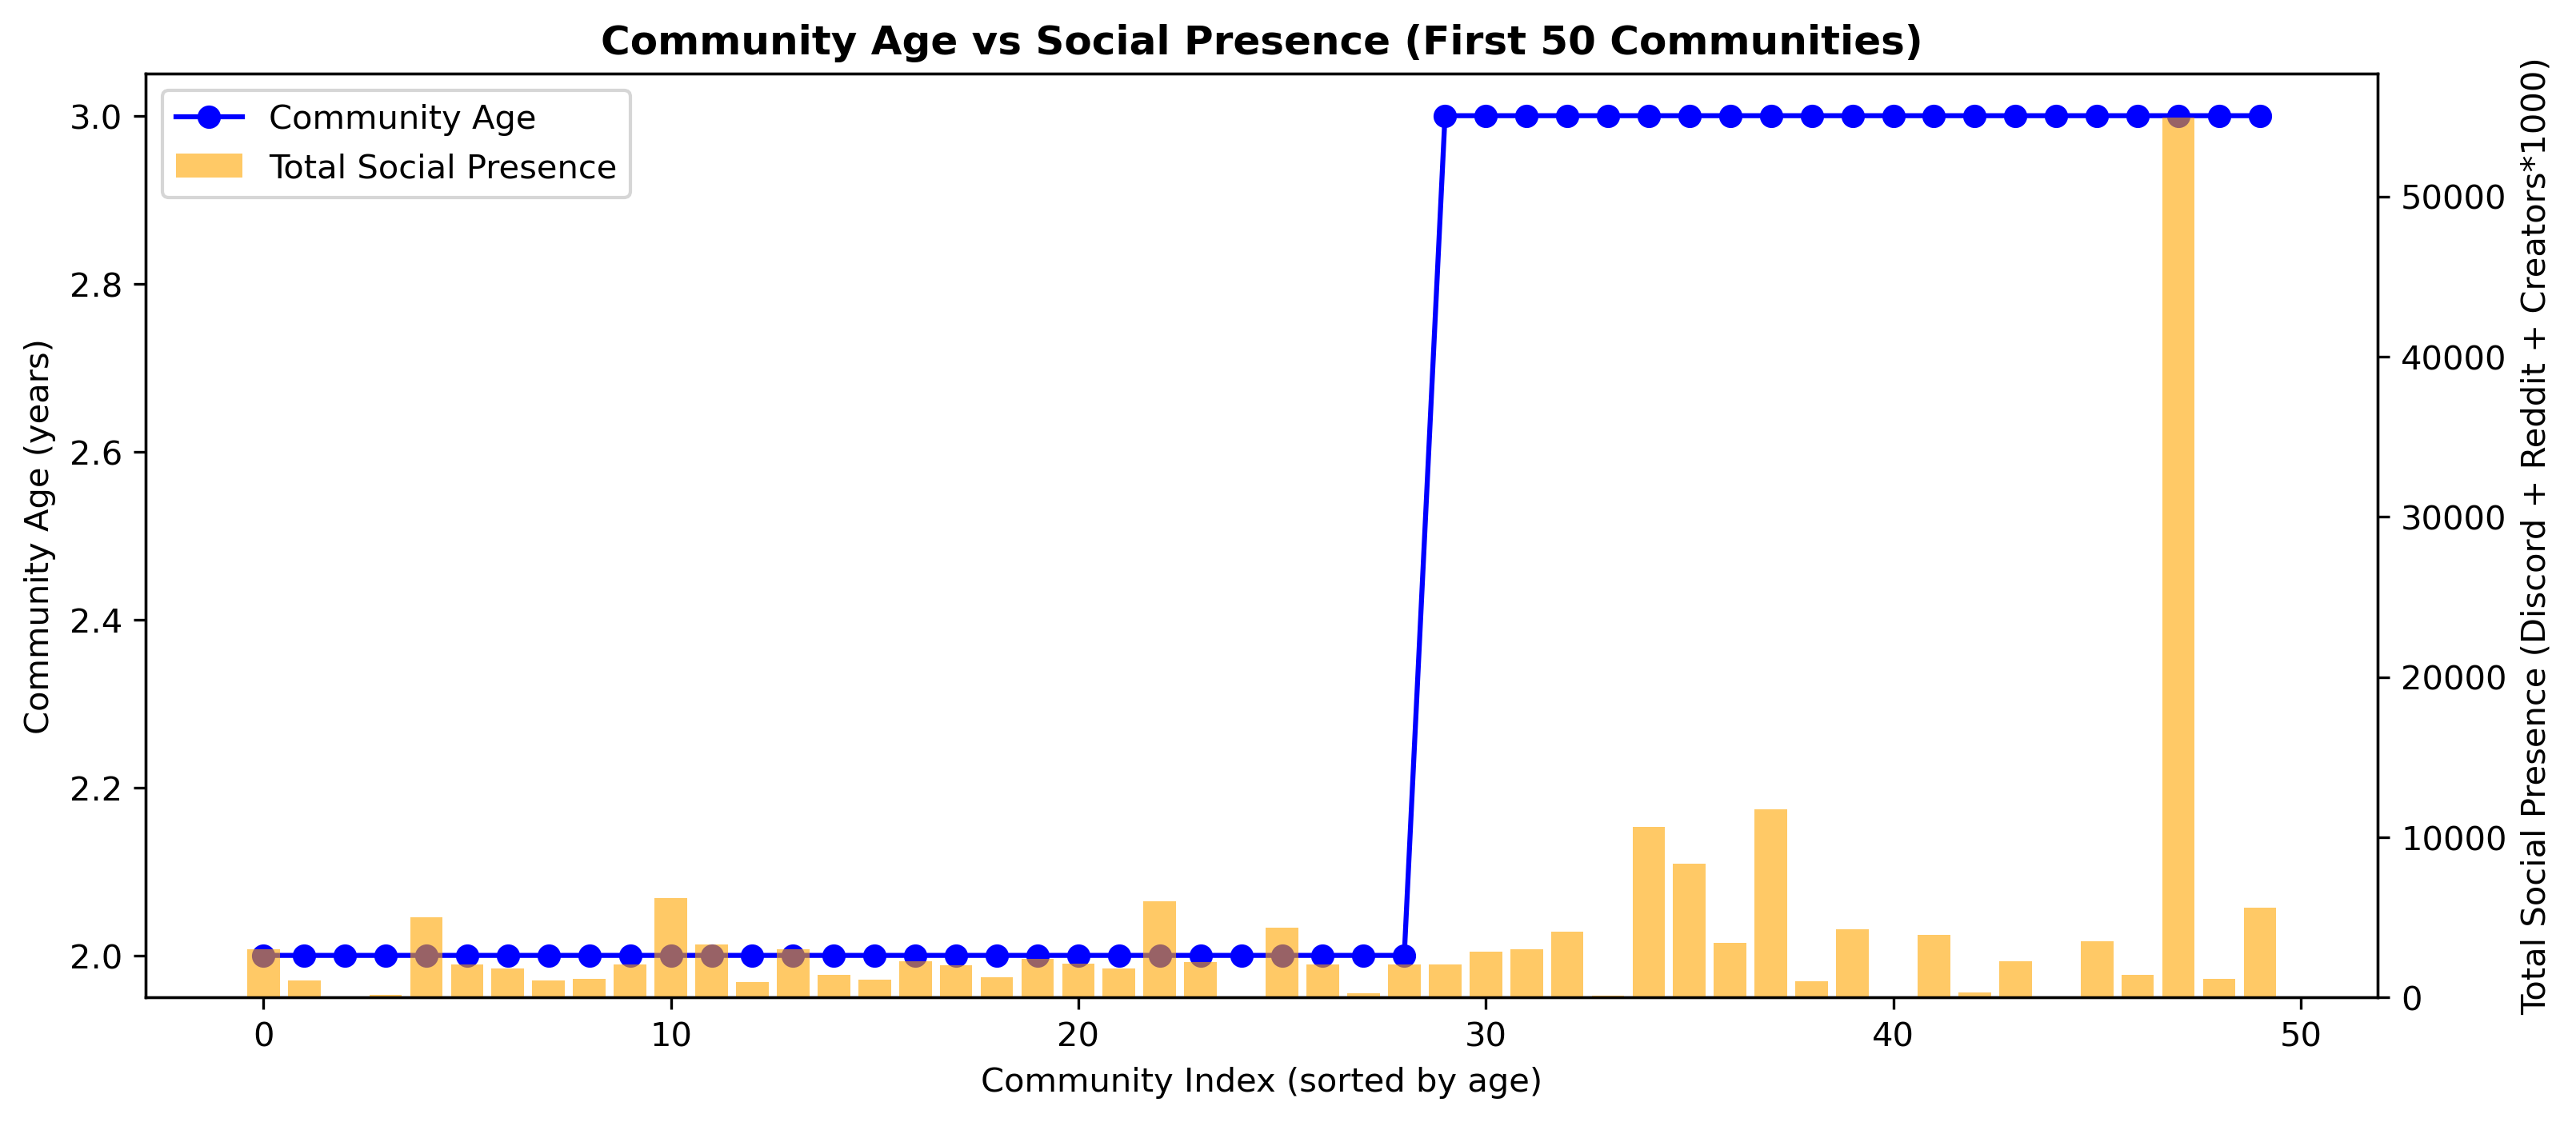

In [82]:
#Dual‑Axis Plot: Community Age (line) vs Total Social Presence (bars)
data = gaming_data.sort_values('community_age').head(50)
x = range(len(data))
fig, ax = plt.subplots(figsize=(12, 5), dpi=300)
ax.plot(
    x,
    data['community_age'],
    color='blue',
    marker='o',
    linestyle='-',
    label='Community Age'
)
ax2 = ax.twinx()
ax2.bar(
    x,
    data['total_social_presence'],
    color='orange',
    alpha=0.6,
    label='Total Social Presence'
)

lines, labels1 = ax.get_legend_handles_labels()
bars, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + bars, labels1 + labels2, loc='upper left')

ax.set_title("Community Age vs Social Presence (First 50 Communities)", fontweight='bold')
ax.set_xlabel("Community Index (sorted by age)")
ax.set_ylabel("Community Age (years)")
ax2.set_ylabel("Total Social Presence (Discord + Reddit + Creators*1000)")

plt.show()

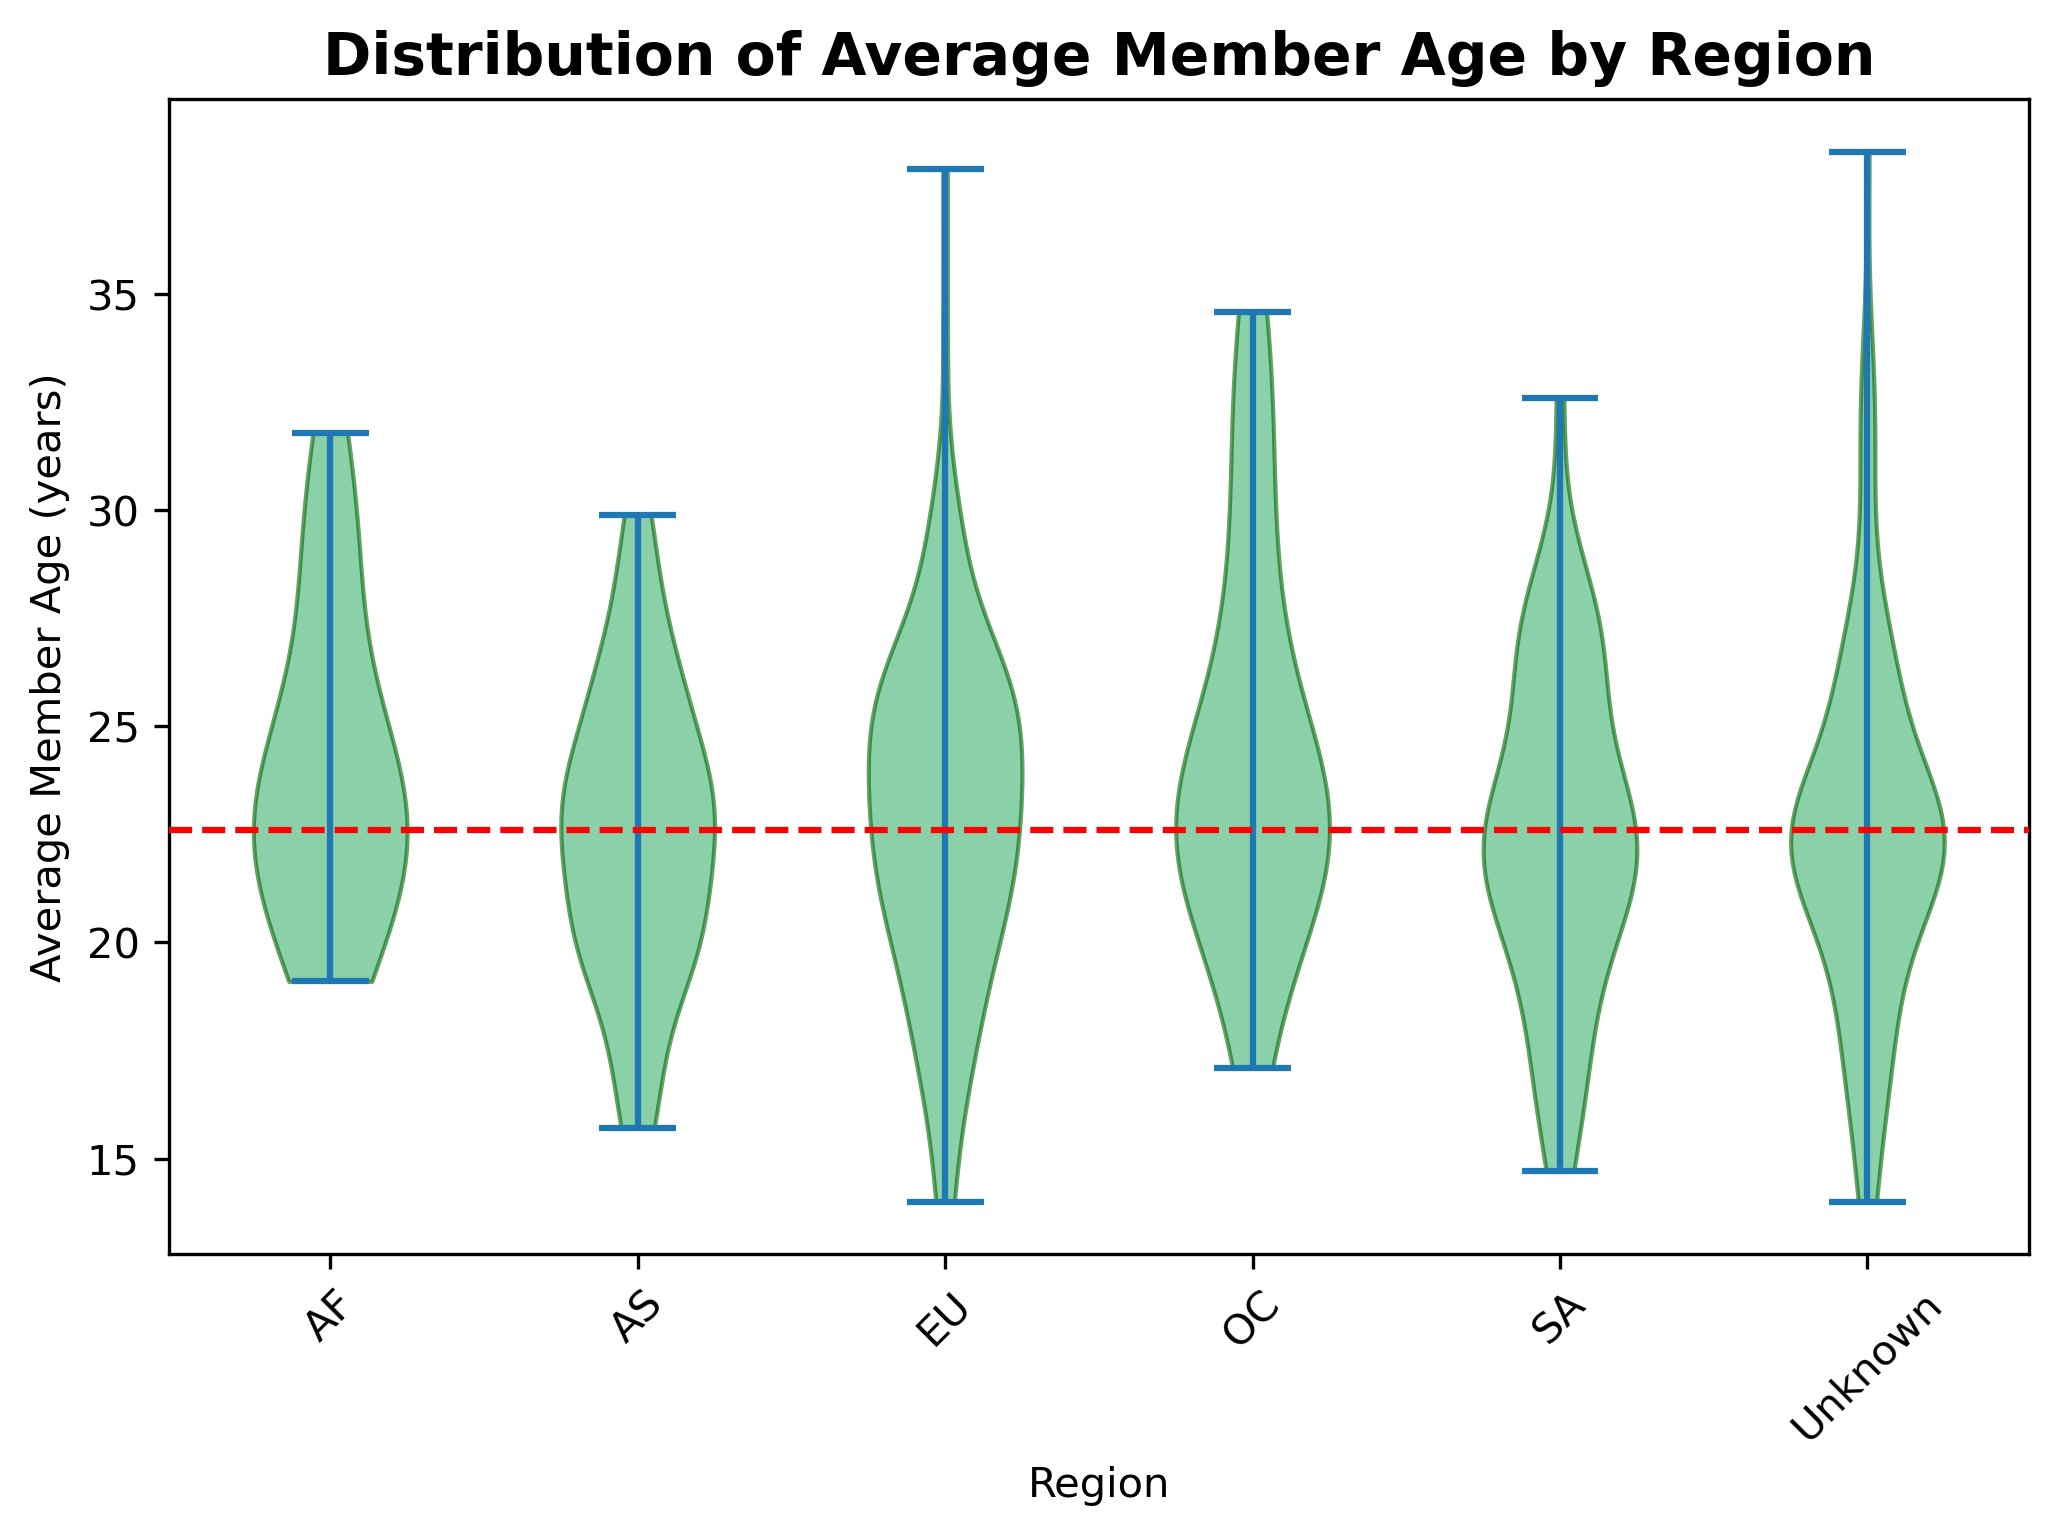

In [95]:
#Violin Plot of Average Member Age by Region
data = gaming_data.groupby('region')['avg_member_age'].apply(list)
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
vio = ax.violinplot(
    data,
    showmeans=False,
    showmedians=False
)
for col in vio['bodies']:
    col.set_facecolor('mediumseagreen')
    col.set_alpha(0.6)
    col.set_edgecolor('darkgreen')
    
ax.set_xticks(range(1, len(data) + 1))
ax.set_xticklabels(data.index)
plt.xticks(rotation=45)

global_median = gaming_data['avg_member_age'].median()
ax.axhline(
    y=global_median,
    linestyle='--',
    color='red',
    linewidth=1.5,
    zorder=3
)

ax.set_title("Distribution of Average Member Age by Region", fontweight='bold', fontsize=14)
ax.set_xlabel("Region")
ax.set_ylabel("Average Member Age (years)")

plt.show()

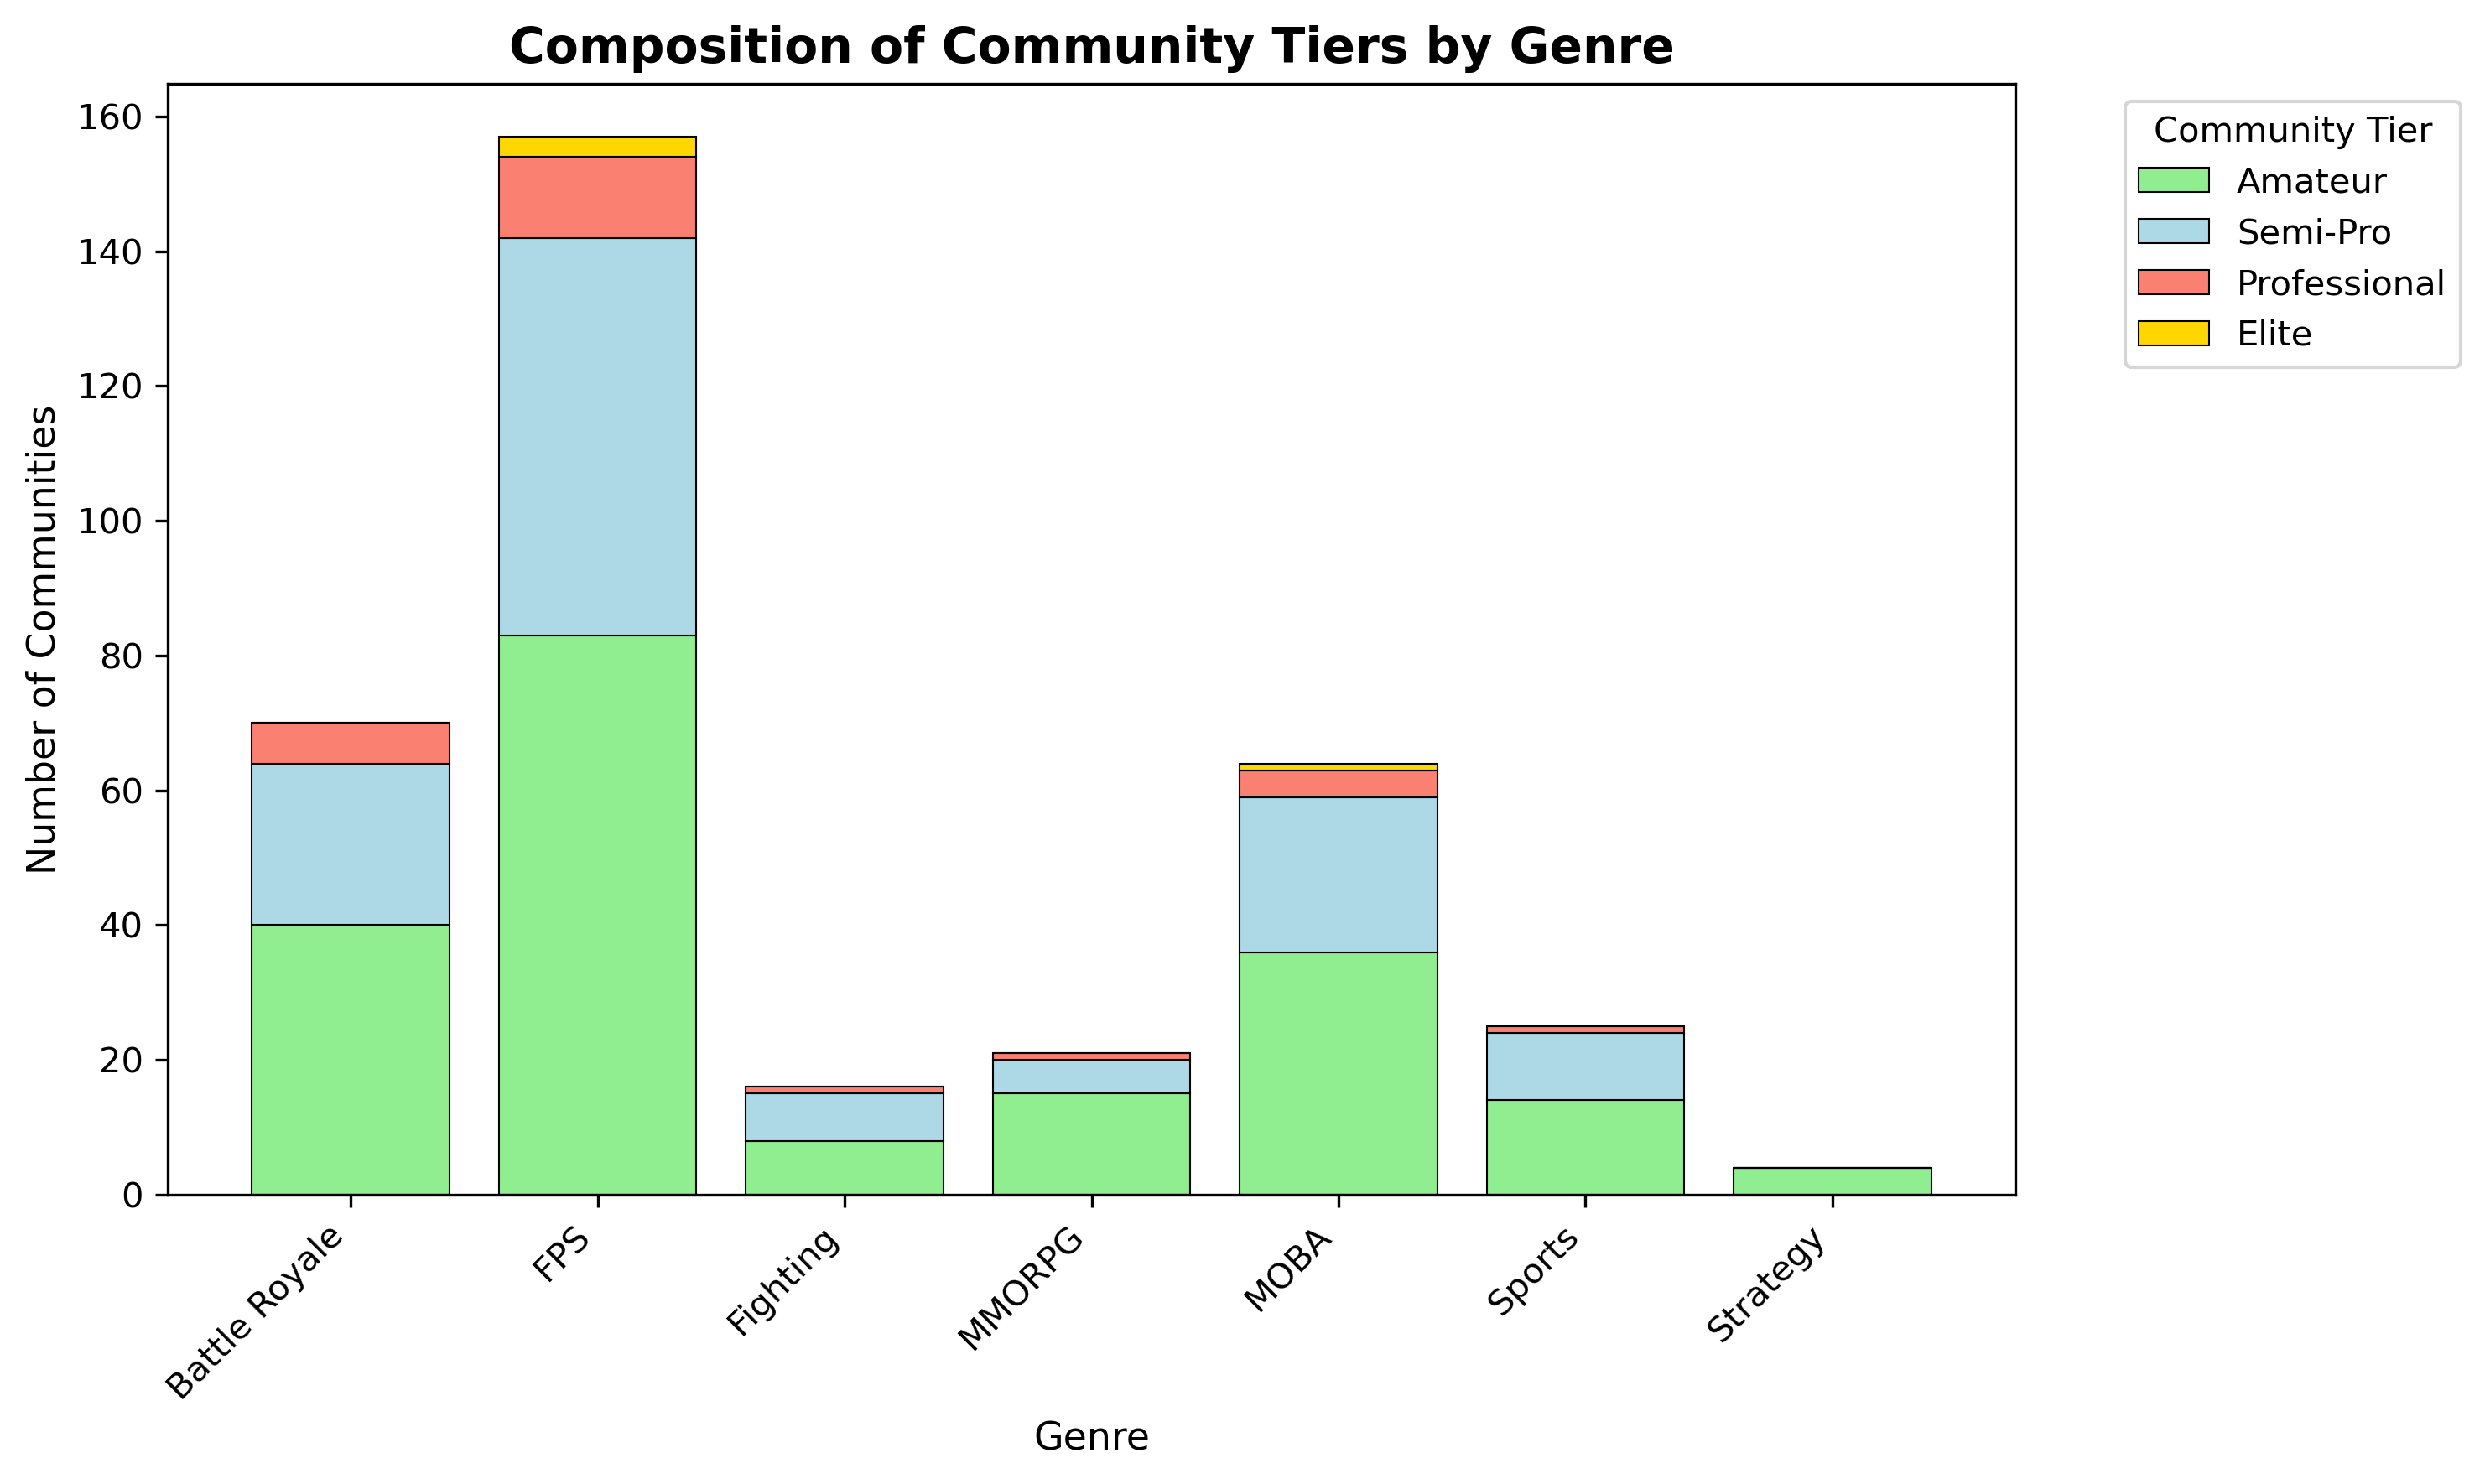

In [105]:
#Stacked Bar Chart: Community Tiers per Genre
tier_counts = pd.crosstab(gaming_data['genre'], gaming_data['community_tier'])
tiers_order = ['Amateur', 'Semi-Pro', 'Professional', 'Elite']
tier_counts = tier_counts.reindex(columns=tiers_order, fill_value=0)

fig, ax = fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
genres = tier_counts.index
colors = ['lightgreen','lightblue','salmon','gold']
bottom_vals = np.zeros(len(genres))

for i, tier in enumerate(tiers_order):
    ax.bar(
        genres,
        tier_counts[tier],
        bottom=bottom_vals,
        label=tier,
        color=colors[i],
        edgecolor='black',
        linewidth=0.5
    )
    bottom_vals += tier_counts[tier].values

ax.legend(title="Community Tier", bbox_to_anchor=(1.05, 1), loc='upper left')

ax.set_title("Composition of Community Tiers by Genre", fontweight='bold', fontsize=14)
ax.set_xlabel("Genre", fontsize=11)
ax.set_ylabel("Number of Communities", fontsize=11)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

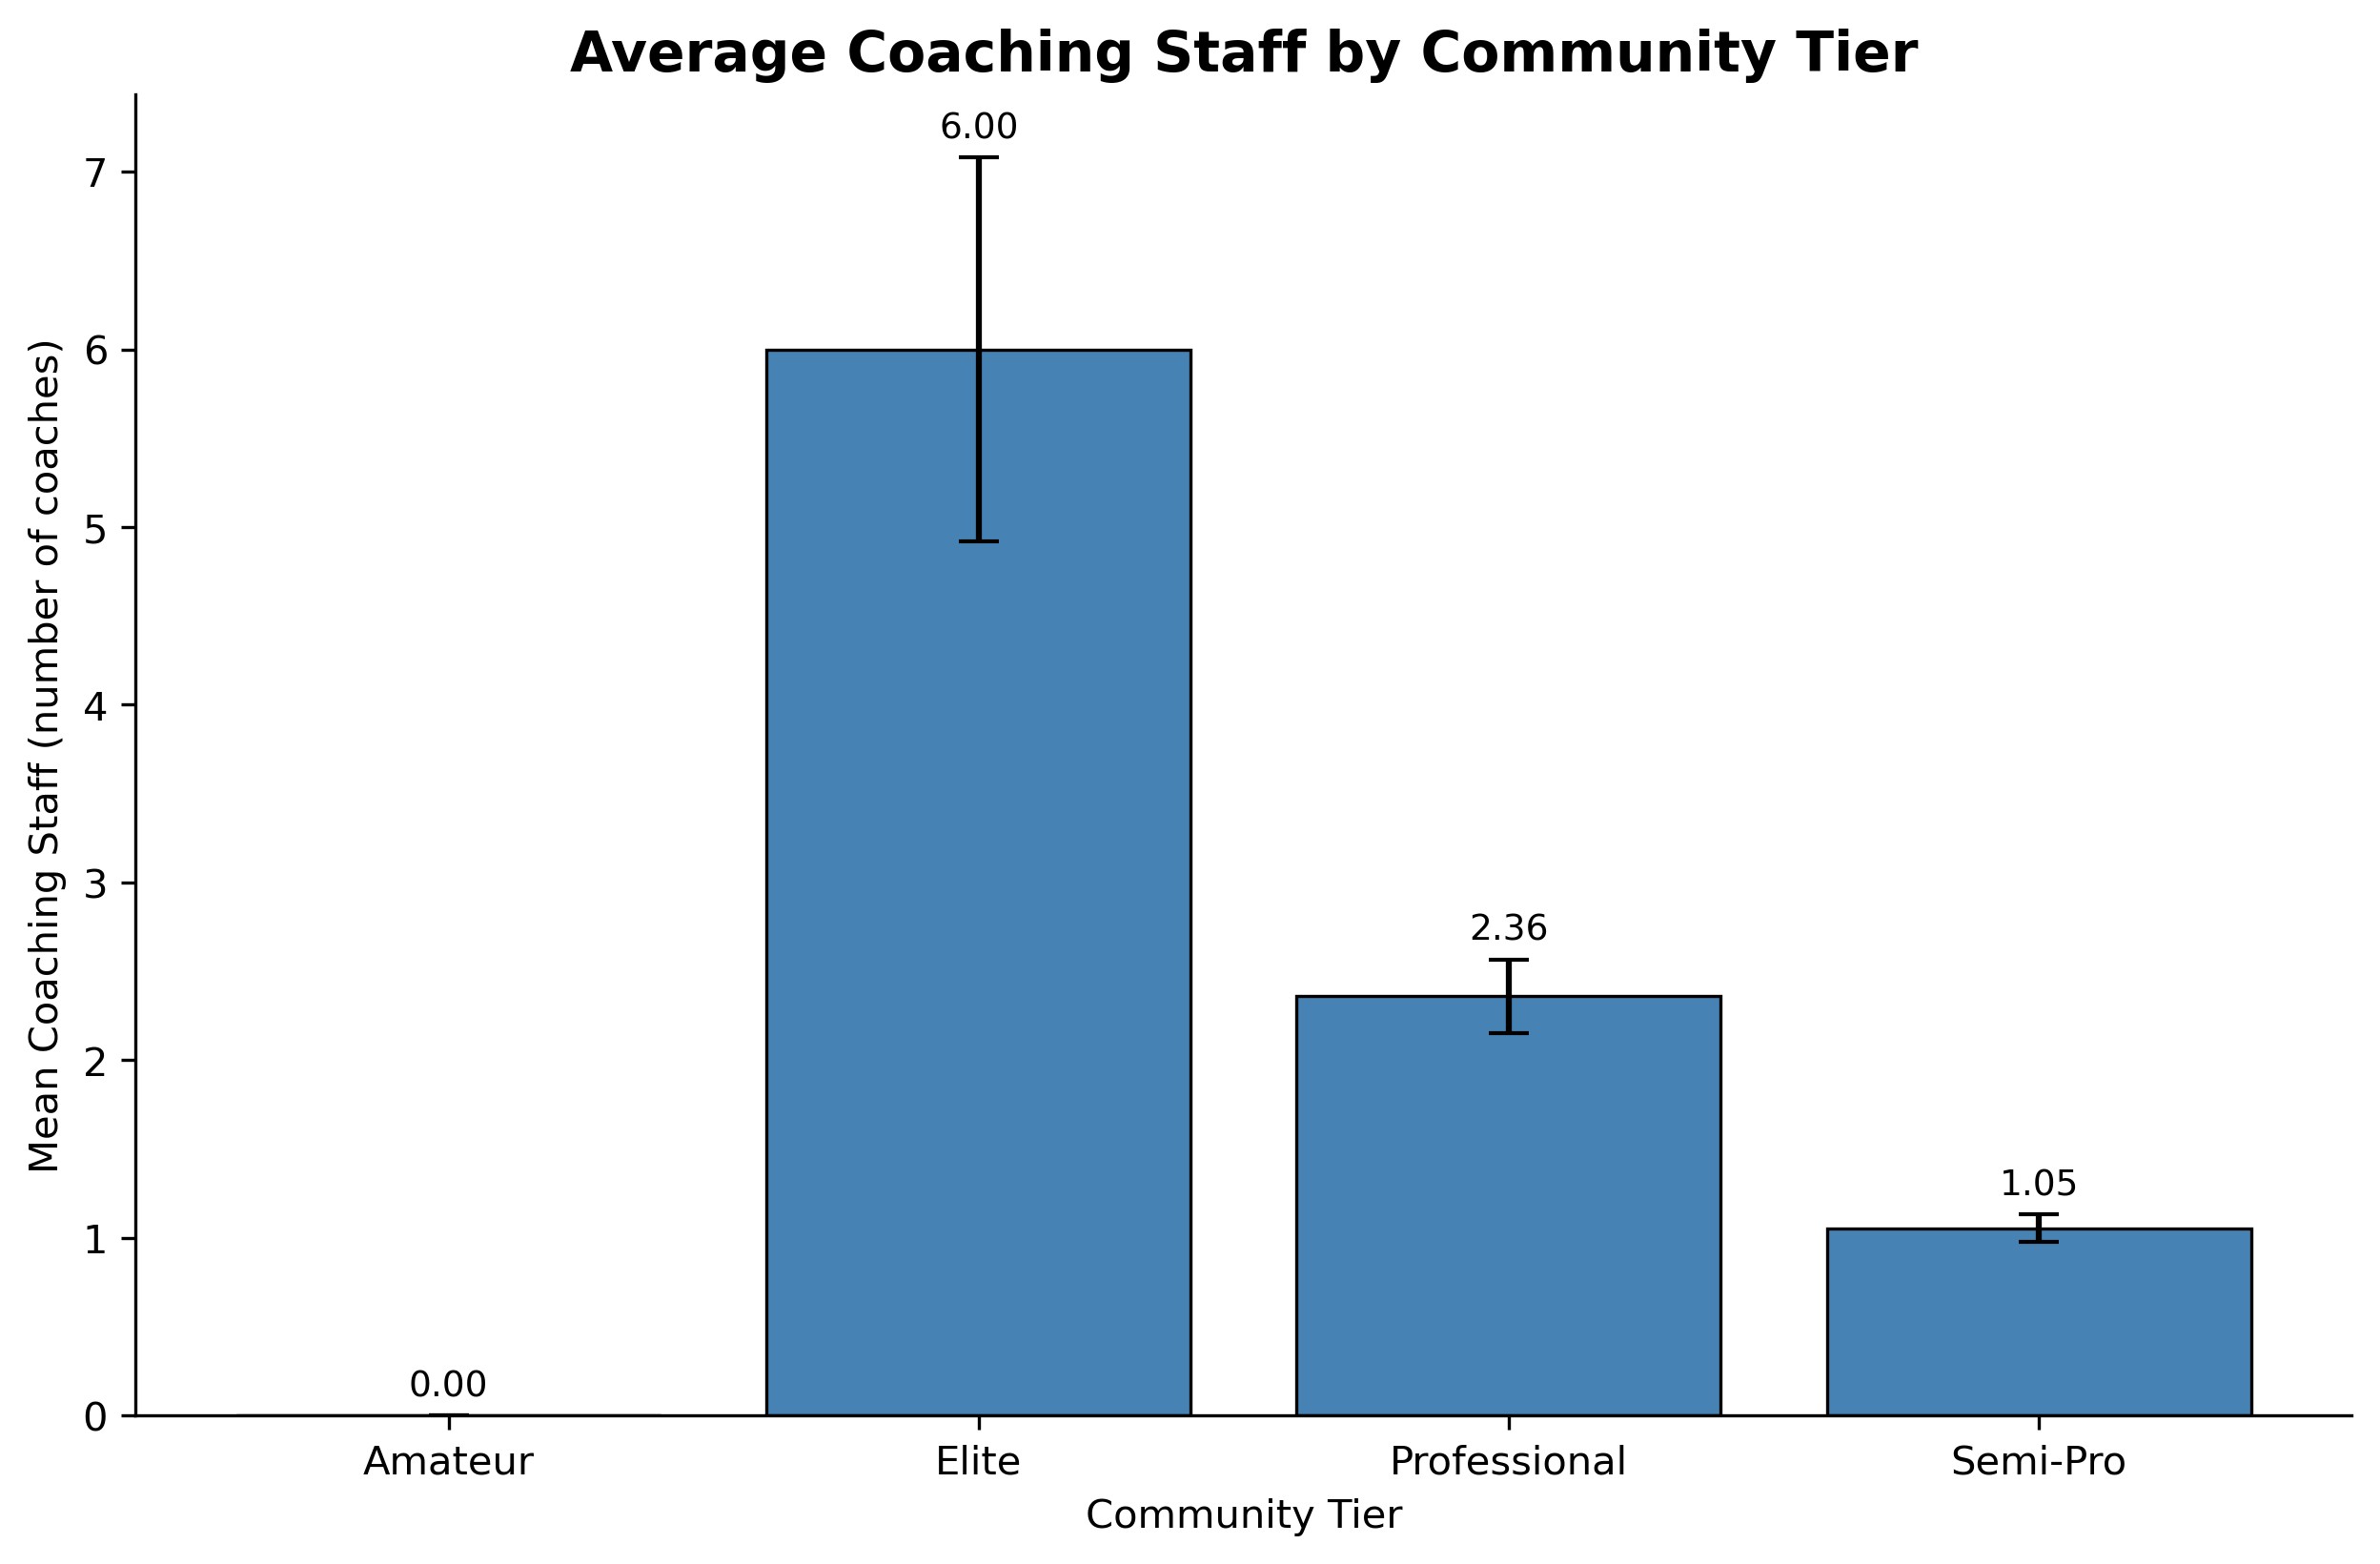

In [117]:
#Error Bar Chart: Mean Coaching Staff per Tier
data = gaming_data.groupby('community_tier')['coaching_staff'].agg(['mean', 'std', 'count'])
data['sem'] = data['std'] / np.sqrt(data['count'])
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
bars = ax.bar(
    data.index,
    data['mean'],
    yerr=data['sem'],
    capsize=5,
    color='steelblue', 
    edgecolor='black', 
    linewidth=0.8
)
ax.bar_label(bars, padding=3, fontsize=9, fmt='%.2f')
ax.set_title("Average Coaching Staff by Community Tier", fontsize=14, fontweight='bold')
ax.set_xlabel("Community Tier")
ax.set_ylabel("Mean Coaching Staff (number of coaches)")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

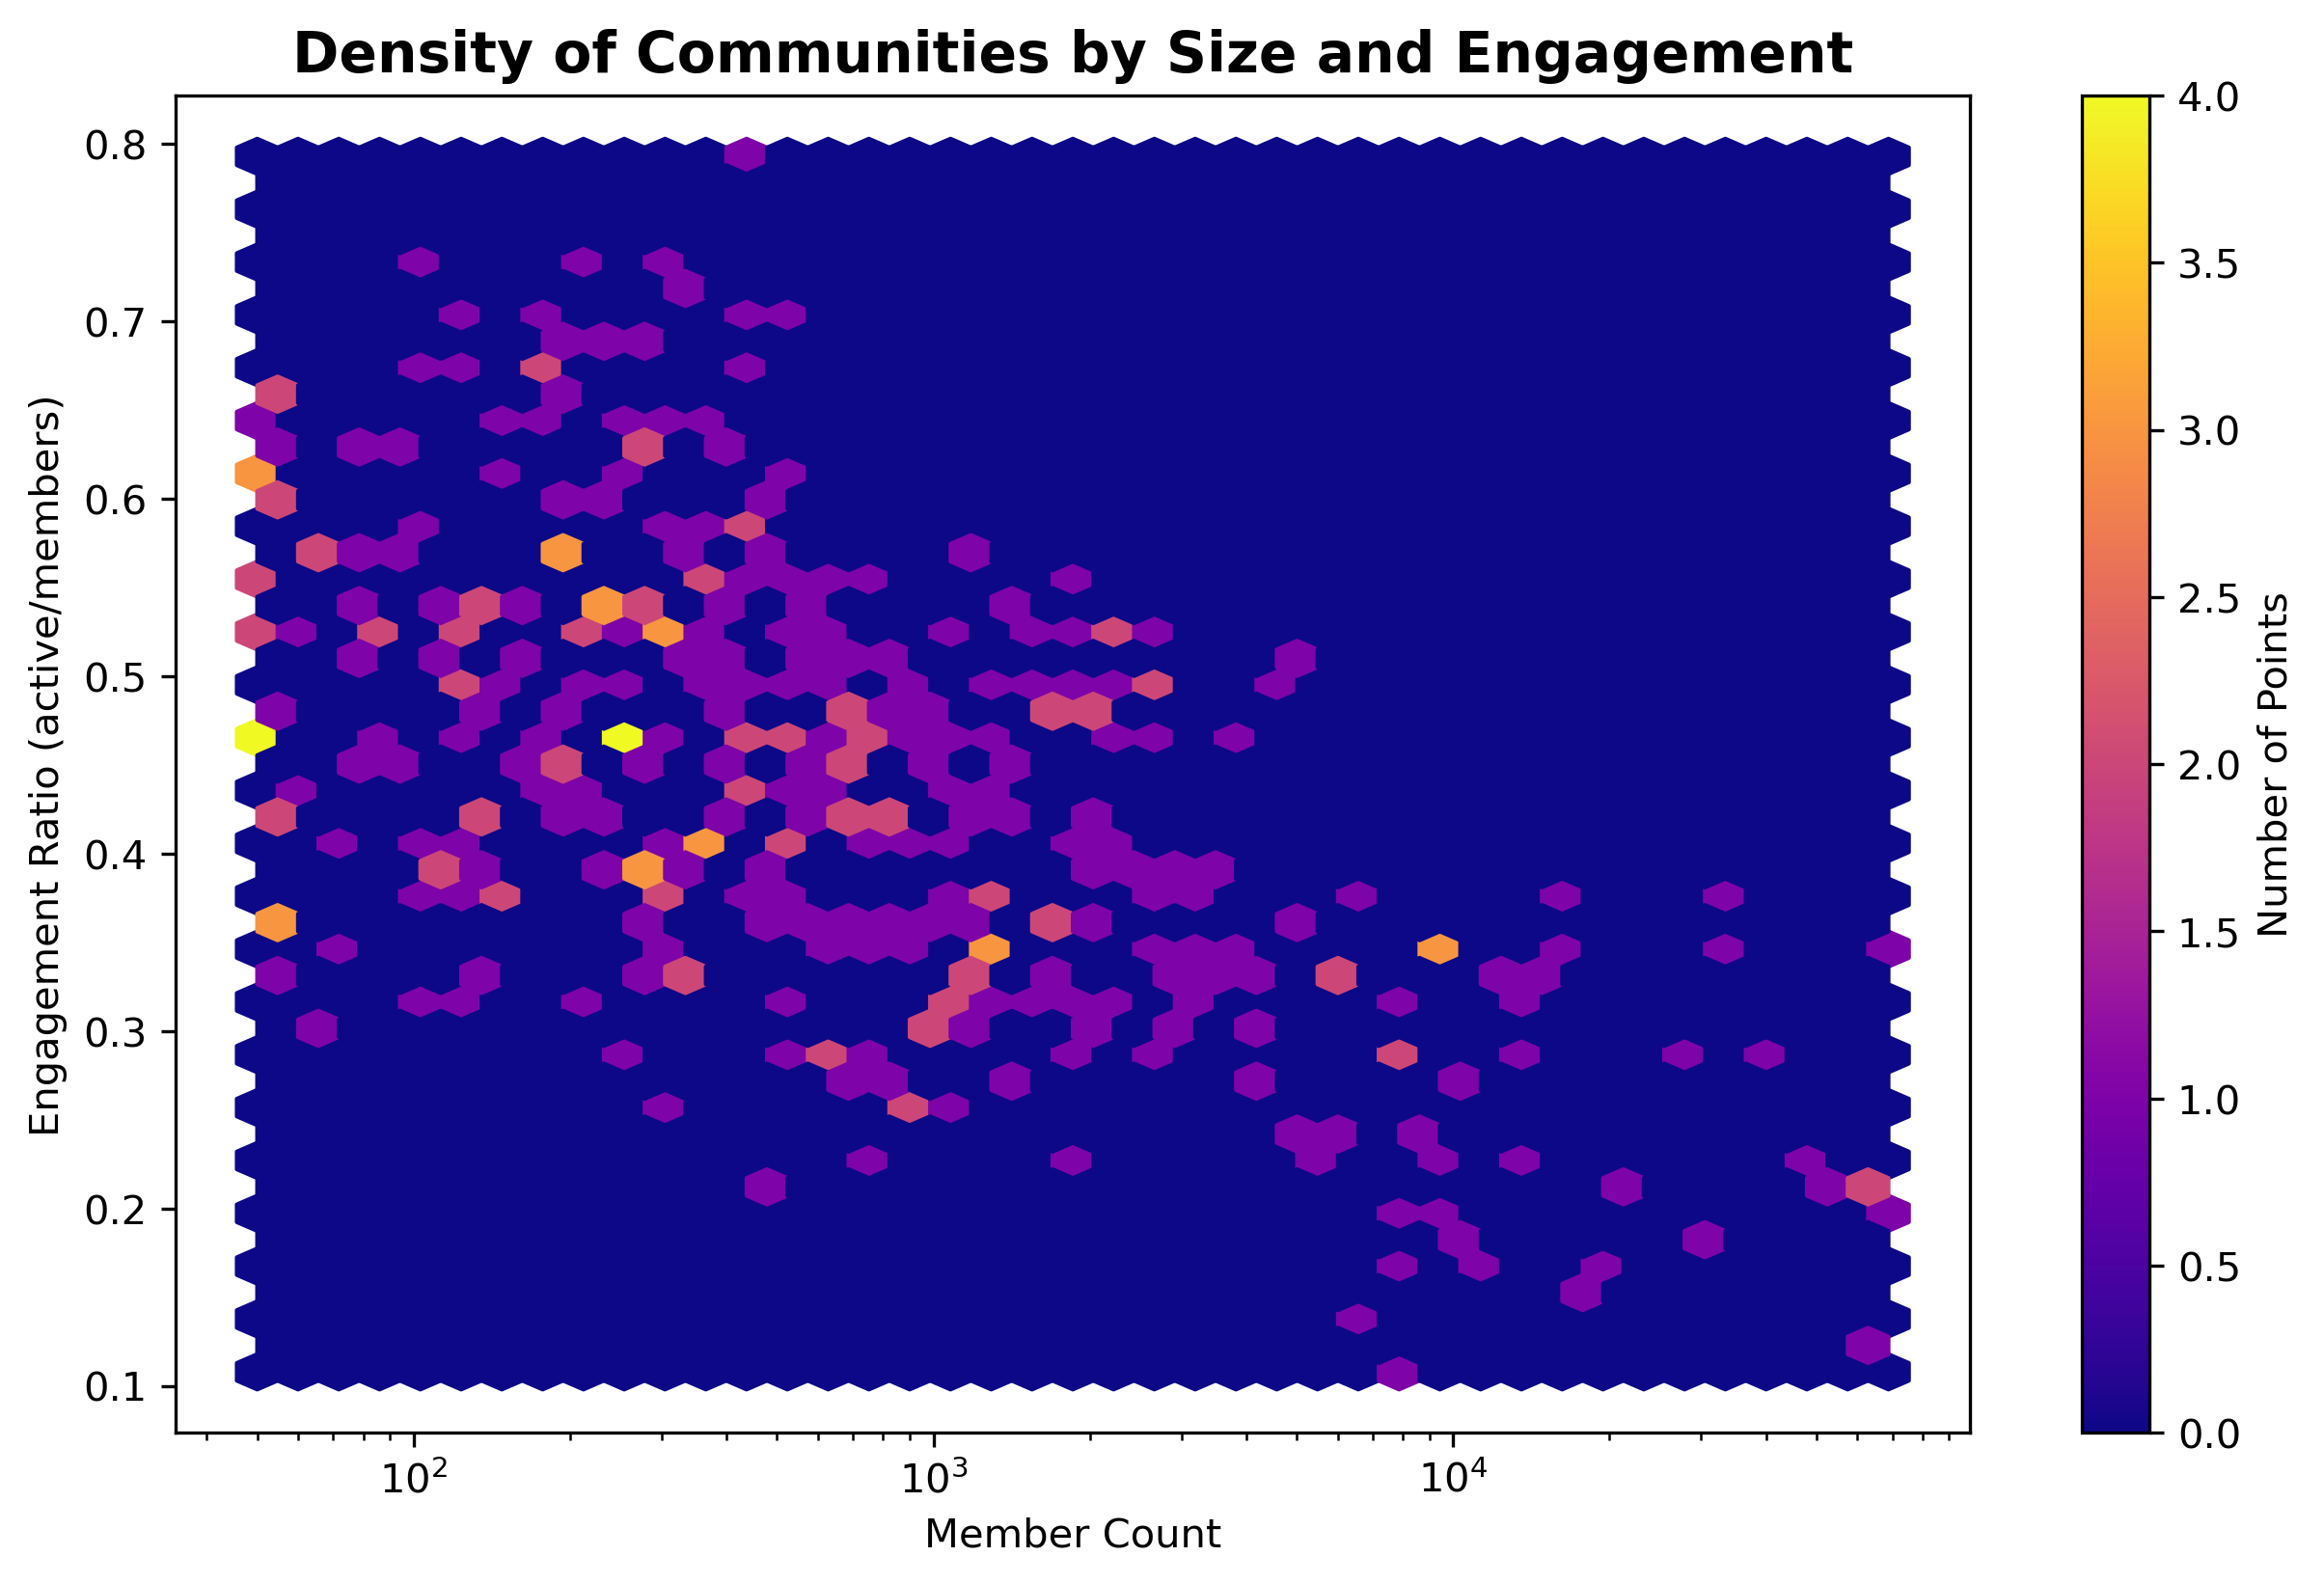

In [126]:
#Hexbin Heatmap: Member Count vs Engagement Ratio
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
hb = ax.hexbin(gaming_data['member_count'], gaming_data['engagement_ratio'], cmap='plasma', gridsize=40, xscale='log')
cb = fig.colorbar(hb, ax=ax)
cb.set_label('Number of Points')

ax.set_title("Density of Communities by Size and Engagement", fontsize=14, fontweight='bold')
ax.set_xlabel("Member Count")
ax.set_ylabel("Engagement Ratio (active/members)")

plt.show()

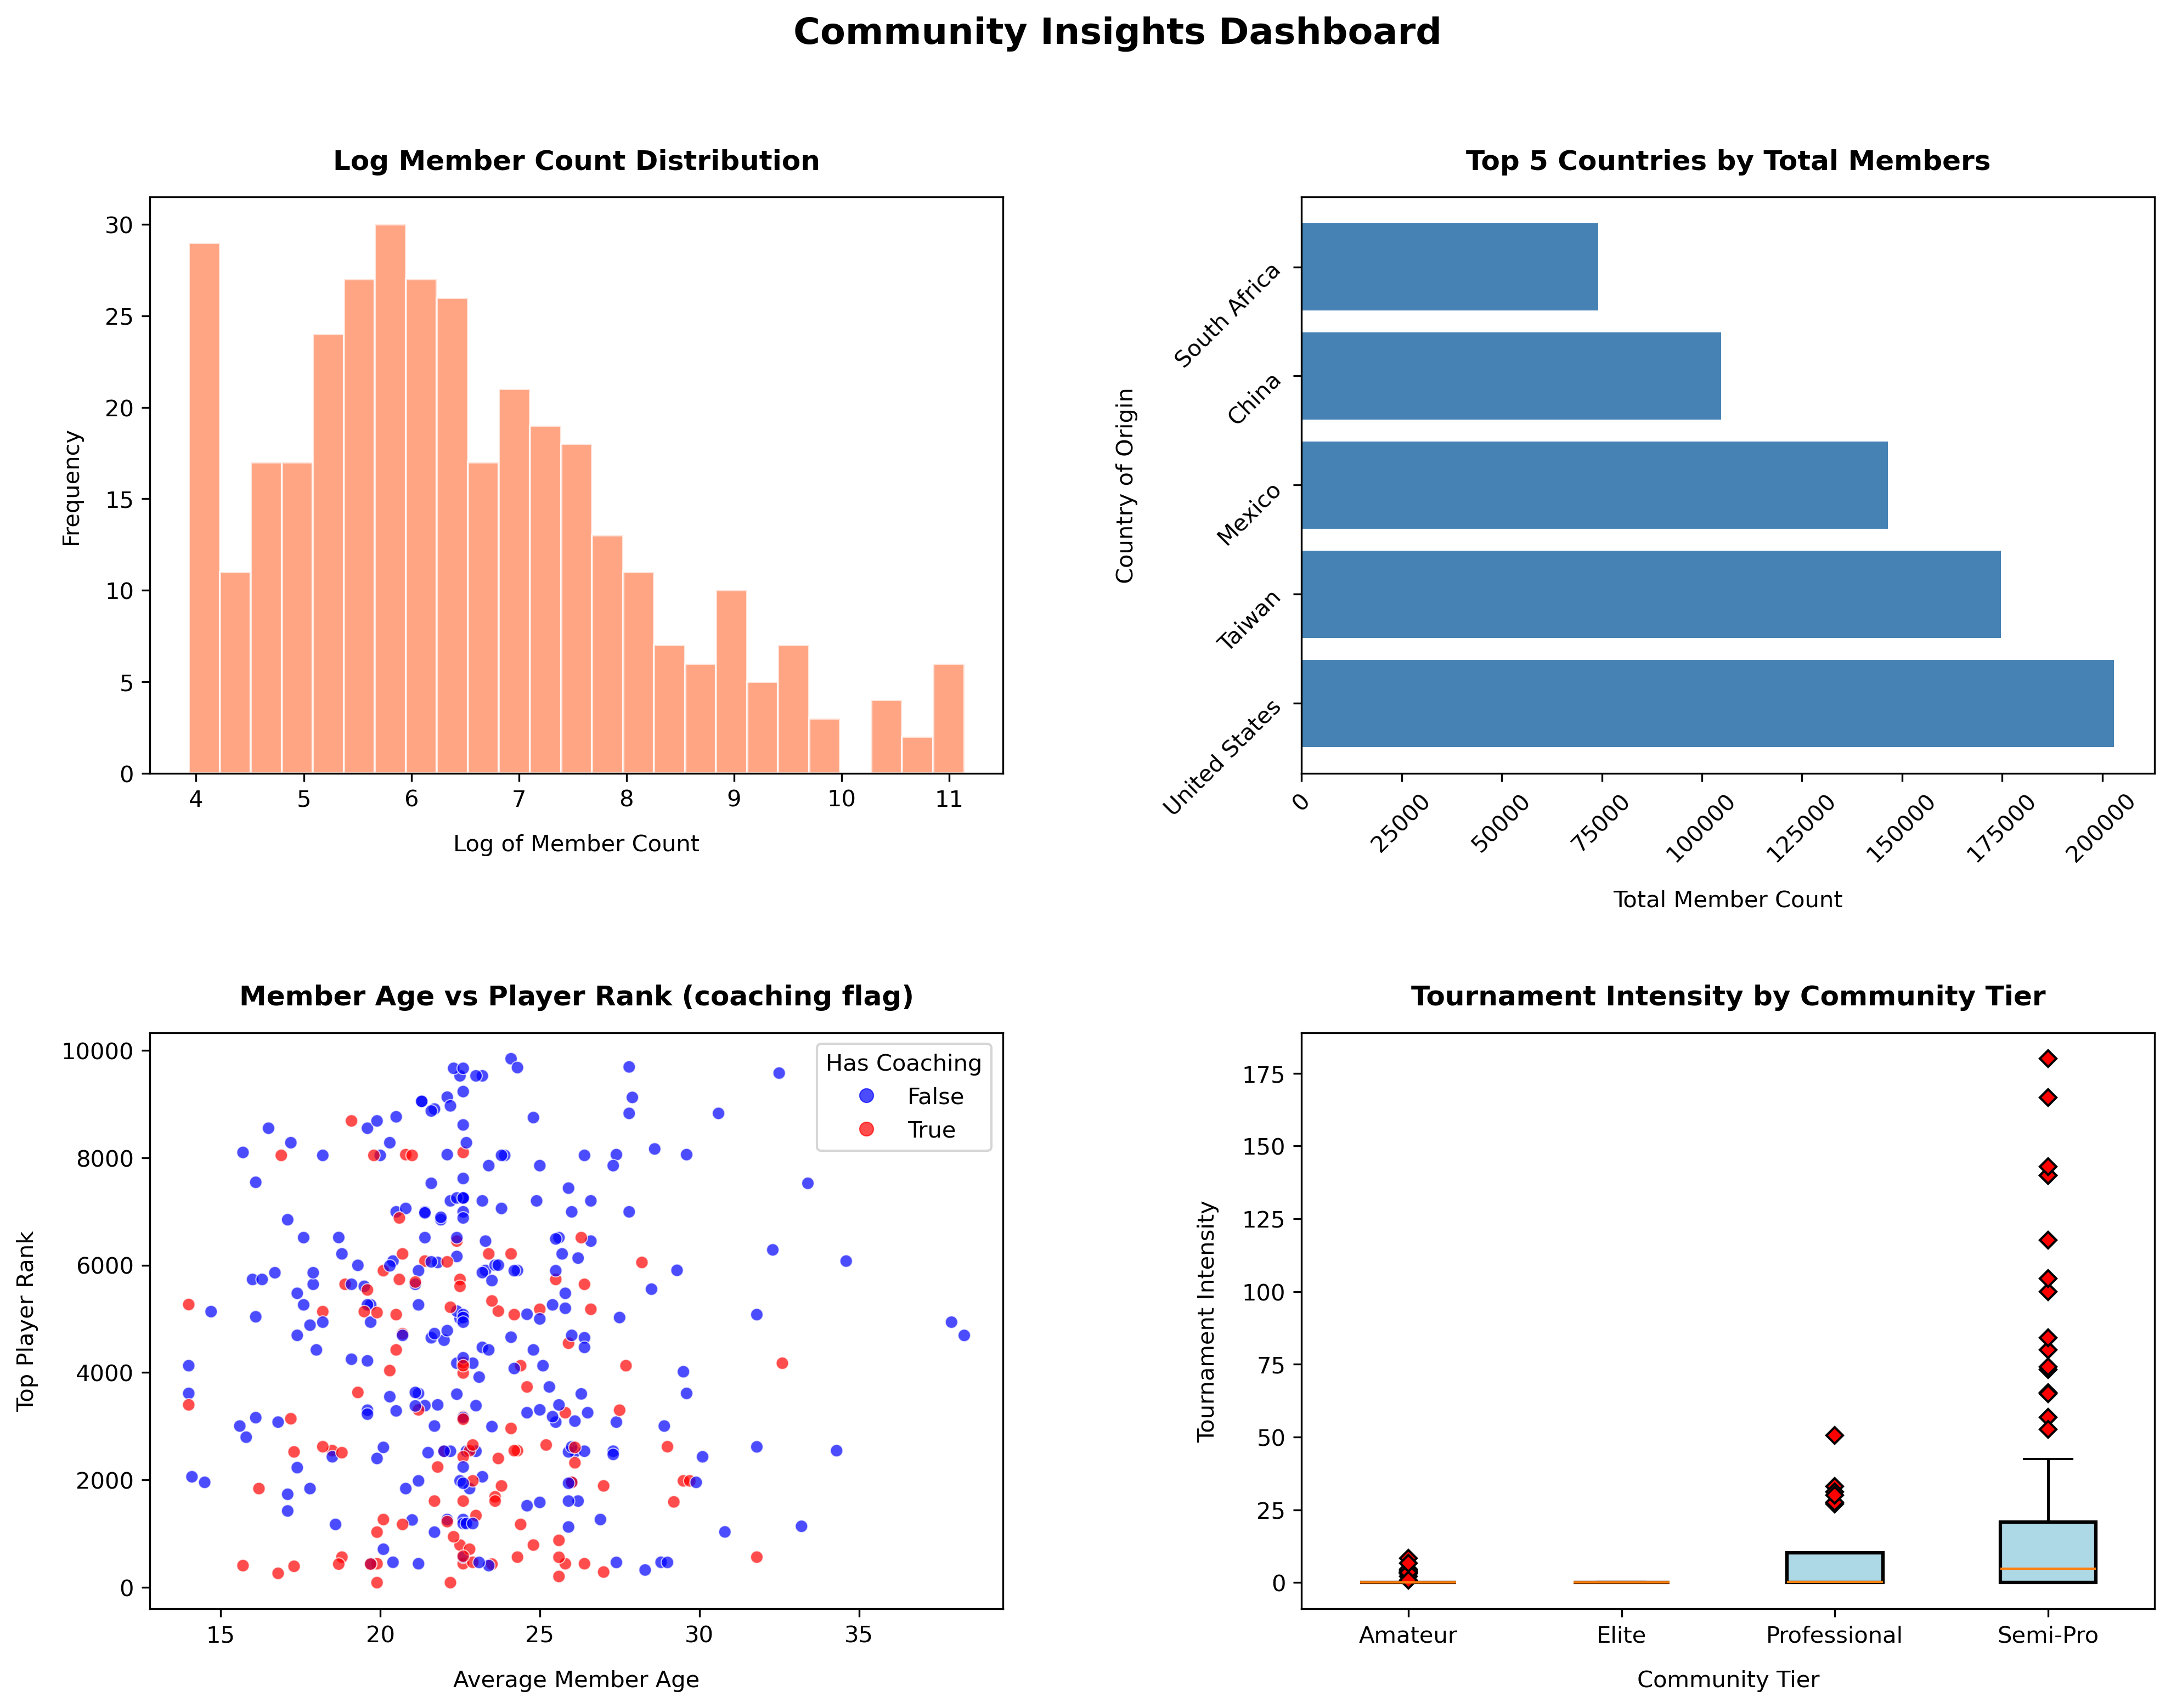

In [163]:
#2×2 Subplot Dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 11), dpi=300)

#top-left
axes[0][0].hist(
        gaming_data['log_member_count'],
        bins=25,
        color='coral',
        edgecolor='white', 
        alpha=0.7
       )
axes[0][0].set_title("Log Member Count Distribution", fontsize=12, pad=12, fontweight='bold')
axes[0][0].set_xlabel("Log of Member Count", labelpad=10)
axes[0][0].set_ylabel("Frequency", labelpad=10)

#top-right
data = gaming_data.groupby('country_of_origin')['member_count'].sum().nlargest(5)
bars = axes[0][1].barh(
    y=data.index,
    width=data,
    color='steelblue'
)
axes[0][1].tick_params(axis='x', rotation=45)
axes[0][1].tick_params(axis='y', rotation=45)
axes[0][1].set_title("Top 5 Countries by Total Members", fontsize=12, pad=12, fontweight='bold')
axes[0][1].set_xlabel("Total Member Count", labelpad=10)
axes[0][1].set_ylabel("Country of Origin", labelpad=10)

#bottom-left
coaching_cats = gaming_data['has_coaching'].astype('category')
coaching_codes = coaching_cats.cat.codes
coaching_names = coaching_cats.cat.categories

scatter_bl = axes[1][0].scatter(
    x=gaming_data['avg_member_age'],
    y=gaming_data['top_player_rank'],
    c=coaching_codes,
    cmap='bwr',
    alpha=0.7,
    s=30,
    edgecolor='white',
    linewidth=0.5
)

handles_bl, _ = scatter_bl.legend_elements()
axes[1][0].legend(handles_bl, coaching_names, title="Has Coaching")
axes[1][0].set_title("Member Age vs Player Rank (coaching flag)", fontsize=12, pad=12, fontweight='bold')
axes[1][0].set_xlabel("Average Member Age", labelpad=10)
axes[1][0].set_ylabel("Top Player Rank", labelpad=10)

#bottom right
data = gaming_data.groupby('community_tier')['tournament_intensity'].apply(list)
axes[1][1].boxplot(
    data,
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', linewidth=1.5),
    tick_labels=data.index,
    flierprops=dict(marker='D', markerfacecolor='red', markersize=5),
    whiskerprops=dict(linewidth=1.2)
)
axes[1][1].set_title("Tournament Intensity by Community Tier", fontsize=12, pad=12, fontweight='bold')
axes[1][1].set_xlabel("Community Tier", labelpad=10)
axes[1][1].set_ylabel("Tournament Intensity", labelpad=10)

fig.suptitle("Community Insights Dashboard", fontsize=16, fontweight='bold', y=0.96)


plt.subplots_adjust(left=0.08, right=0.95, bottom=0.08, top=0.86, wspace=0.35, hspace=0.45)

plt.show()